# imports

In [1]:
# imports

import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import PowerTransformer
from sklearn import neighbors, metrics

%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn

pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

In [2]:
#imp_med = SimpleImputer(missing_values=np.nan, strategy='median')
#imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')

In [3]:
path = './data/'
csv_path = path + 'to_input_openfoodfacts.csv'
#csv_path = path + 'en.openfoodfacts.org.products.csv'
sm_df = pd.read_csv(csv_path, low_memory=False)

# Dataframe info

## functions

In [4]:
def get_df_columns_na(df):
    nan_values = df.isnull().sum()
    nan_percent = nan_values /df.shape[0]*100
    nan_info = pd.concat([nan_values,nan_percent],axis=1)
    nan_info.columns = ['count', 'null_percent']
    nan_info = nan_info.sort_values(by='null_percent',ascending=True)
    return nan_info

In [5]:
def plot_df_xy(df, x_val, y_val, height_val = 20, width_val = 13):
    sns.catplot(data=df, x= x_val, y= y_val, kind="bar", height=height_val, aspect=width_val/height_val)
    sns.set(rc={'figure.figsize':(width_val,height_val)})
    plt.xticks(rotation=70)
    plt.tight_layout()

In [6]:
def show_nulls(df, display=False):
    df_nulls = get_df_columns_na(df).sort_values(by='null_percent',ascending=False)
    print(df_nulls)
    if display == True:
        plot_df_xy(df_nulls.reset_index(), 'null_percent', 'index', 7)

In [7]:
def boxplot_nums(df, cols_lists, log=False):
    sns.set(rc={'figure.figsize':(11.7,8.27)})
    
    col_lists_len = len(cols_lists)
    all_lists_len = []
    iter = 0
    for i in cols_lists:
        all_lists_len.append(len(i))
    
    fig, ax  = plt.subplots(1,col_lists_len, gridspec_kw={'width_ratios': all_lists_len})
    
    for i in cols_lists:
        if log==True:
            sns.boxplot(data=np.log(df[i]), ax=ax[iter]
                        , showmeans=True
                        , meanprops={"marker":"s","markerfacecolor":"white", "markeredgecolor":"green"}
                       )
        else:
            sns.boxplot(data=df[i], ax=ax[iter]
                        , showmeans=True
                        , meanprops={"marker":"s","markerfacecolor":"white", "markeredgecolor":"green"}
                       )
        ax[iter].set_xticklabels(ax[iter].get_xticklabels(),rotation=55)
        iter+=1
    
    plt.show()

In [8]:
def boxplot_nums(df, cols_lists):
    sns.set(rc={'figure.figsize':(11.7,8.27)})
    
    col_lists_len = len(cols_lists)
    all_lists_len = []
    iter = 0
    for i in cols_lists:
        all_lists_len.append(len(i))
    
    fig, ax  = plt.subplots(1,col_lists_len, gridspec_kw={'width_ratios': all_lists_len})
    
    for i in cols_lists:
        sns.boxplot(data=df[i], ax=ax[iter])
        ax[iter].set_xticklabels(ax[iter].get_xticklabels(),rotation=55)
        iter+=1
    plt.show()

In [9]:
def UVA_numeric2(data, i):
  '''
  Univariate_Analysis_numeric
  takes a group of variables (INTEGER and FLOAT) and plot/print all the descriptives and properties along with KDE.

  Runs a loop: calculate all the descriptives of i(th) variable and plot/print it
  '''
  # calculating descriptives of variable
  mini = data[i].min()
  maxi = data[i].max()
  ran = data[i].max()-data[i].min()
  mean = data[i].mean()
  median = data[i].median()
  st_dev = data[i].std()
  skew = data[i].skew()
  kurt = data[i].kurtosis()

  # calculating points of standard deviation
  points = mean-st_dev, mean+st_dev
    

  #fig, ax = plt.subplots()
  sns.kdeplot(data[i]
                  #, shade=True
                  , fill=True
                )
    
  max_ax = (sns.kdeplot(data[i]).lines[0].get_xydata())[:, 1].max()
  y_line = [max_ax/100, max_ax/100]
  y_point = [max_ax/100]
    
  sns.lineplot(x = points, y=y_line, color = 'black', label = "marg_err")
  sns.scatterplot(x=[mini,maxi], y=y_line, color = 'orange', label = "min/max")
  sns.scatterplot(x=[mean], y=y_point, color = 'red', label = "mean")
  sns.scatterplot(x=[median], y=y_point, color = 'blue', label = "median")
  plt.xlabel('{}'.format(i), fontsize = 20)
  plt.ylabel('density')
  plt.title('margin_error = {}; kurtosis = {};\nskew = {}; range = {}\nmean = {}; median = {}'.format((round(points[0],2),round(points[1],2)),
                                                                                                   round(kurt,2),
                                                                                                   round(skew,2),
                                                                                                   (round(mini,2),round(maxi,2),round(ran,2)),
                                                                                                   round(mean,2),
                                                                                                   round(median,2)))

In [10]:
# afficher détail Boxplot / UVA_num pour chaque indicateur par ligne

def UVA_num_plus(df, indicators_list, label='basic'):
  
    for i in indicators_list:
        plt.figure(figsize = (15, 20))
        df_indic = df[i]

        plt.subplot(5,2,1)
        sns.boxplot(y=df_indic
                    , showmeans=True
                    , meanprops={"marker":"s","markerfacecolor":"white", "markeredgecolor":"green"}
                   )
        plt.xlabel(f'{i}', fontsize = 20)
        if label == 'basic':
            plt.ylabel(f'blop')


        plt.subplot(5,2,2)
        UVA_numeric2(df, i)

In [11]:
def UVA_num_plus_cat(df, indicators_list, cat):
  
    for i in indicators_list:
        plt.figure(figsize = (15, 20))
        df_indic = df[i]

        plt.subplot(5,2,1)
        sns.boxplot(y=df_indic
                    , showmeans=True
                    , meanprops={"marker":"s","markerfacecolor":"white", "markeredgecolor":"green"}
                   )
        plt.xlabel(f'{i}', fontsize = 20)
        plt.ylabel(f'{cat}', fontsize=20)


        plt.subplot(5,2,2)
        UVA_numeric2(df, i)

In [12]:
# Custom function for easy visualisation of Categorical Variables
def UVA_category(data, var_group, width=7, height=5):

  '''
  Univariate_Analysis_categorical
  takes a group of variables (category) and plot/print all the value_counts and barplot.
  '''
  # setting figure_size
  size = len(var_group)
  plt.figure(figsize = (width*size, height), dpi = 100)

  # for every variable
  for j,i in enumerate(var_group):
    norm_count = data[i].value_counts(normalize = True)
    #norm_count_readable = str(round(value*100, 1))
    n_uni = data[i].nunique()

  #Plotting the variable with every information
    plt.subplot(1,size,j+1)
    ax = sns.barplot(x=round(norm_count*100, 2), y=norm_count.index , order = norm_count.index)
    plt.xlabel('fraction/percent', fontsize = 20)
    plt.ylabel('{}'.format(i), fontsize = 20)
    #plt.title('n_uniques = {} \n value counts \n {};'.format(n_uni,norm_count))
    plt.title('n_uniques = {}'.format(n_uni))
    var = ax.bar_label(ax.containers[0], rotation=0, padding=2)
    plt.show()

## General distribution / NaNs 

In [13]:
sm_df.shape

(46254, 15)

In [14]:
sm_df.head()

,code,nutrition_grade_fr,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,product_name,fiber_100g,fat_100g,carbohydrates_100g,pnns_groups_2,pnns_groups_1
0,10187319,d,14.0,0.6,1753.0,0.0100,0.003937,87.7,0.8,Mini Confettis,0.9,NaN,NaN,NaN,NaN
1,10207260,d,14.0,9.5,2406.0,0.0030,0.001181,50.3,2.9,Praliné Amande Et Noisette,3.9,NaN,NaN,NaN,NaN
2,40608754,e,13.0,0.0,177.0,0.0254,0.010000,10.4,0.0,"Pepsi, Nouveau goût !",0.0,0.0,10.4,Sweetened beverages,Beverages
3,69161025,d,15.0,7.5,1079.0,0.8000,0.314961,1.0,11.0,Tarte Poireaux Et Lardons,1.4,NaN,NaN,NaN,NaN
4,87177756,e,13.0,0.0,177.0,0.1000,0.039370,10.4,0.0,7Up,NaN,0.0,10.4,Sweetened beverages,Beverages


In [15]:
sm_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46254 entries, 0 to 46253
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   code                     46254 non-null  int64  
 1   nutrition_grade_fr       46254 non-null  object 
 2   nutrition-score-fr_100g  36796 non-null  float64
 3   proteins_100g            46187 non-null  float64
 4   energy_100g              46015 non-null  float64
 5   salt_100g                46186 non-null  float64
 6   sodium_100g              46187 non-null  float64
 7   sugars_100g              46184 non-null  float64
 8   saturated-fat_100g       46186 non-null  float64
 9   product_name             46254 non-null  object 
 10  fiber_100g               34517 non-null  float64
 11  fat_100g                 29410 non-null  float64
 12  carbohydrates_100g       29364 non-null  float64
 13  pnns_groups_2            27834 non-null  object 
 14  pnns_groups_1         

In [16]:
sm_df.describe()

,code,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g
count,4.625400e+04,36796.000000,46187.000000,46015.000000,46186.000000,46187.000000,46184.000000,46186.000000,34517.000000,29410.000000,29364.000000
mean,3.819760e+12,9.375068,8.002255,902.814028,1.030939,0.406938,8.410142,4.265709,2.082982,9.407097,16.340414
std,4.428525e+12,7.276457,8.175554,666.120119,2.220297,0.903142,14.188582,7.076040,4.110923,12.654028,20.163020
min,1.756000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.248830e+12,3.000000,1.500000,345.500000,0.080000,0.031496,0.800000,0.200000,0.000000,1.000000,2.500000
50%,3.329770e+12,9.000000,5.800000,751.000000,0.650000,0.255906,2.900000,1.400000,1.000000,4.200000,9.400000
75%,3.608581e+12,15.000000,12.000000,1403.000000,1.300000,0.511811,10.000000,5.000000,2.600000,12.900000,20.400000
max,3.661112e+14,36.000000,90.000000,3761.000000,68.200000,49.212598,100.000000,100.000000,100.000000,92.000000,100.000000


In [17]:
sm_df.columns.to_list()

['code',
 'nutrition_grade_fr',
 'nutrition-score-fr_100g',
 'proteins_100g',
 'energy_100g',
 'salt_100g',
 'sodium_100g',
 'sugars_100g',
 'saturated-fat_100g',
 'product_name',
 'fiber_100g',
 'fat_100g',
 'carbohydrates_100g',
 'pnns_groups_2',
 'pnns_groups_1']

In [18]:
sm_num_cols = ['fat_100g', 'saturated-fat_100g',
               'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 
               'salt_100g','sodium_100g',
               'fiber_100g', 'nutrition-score-fr_100g']
energy_cols = ['energy_100g']
scores_cols = ['nutrition-score-fr_100g'
               #'ecoscore_grade'
              ]
macro_nutrients = ['fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g','fiber_100g']
salt = ['salt_100g', 'sodium_100g']

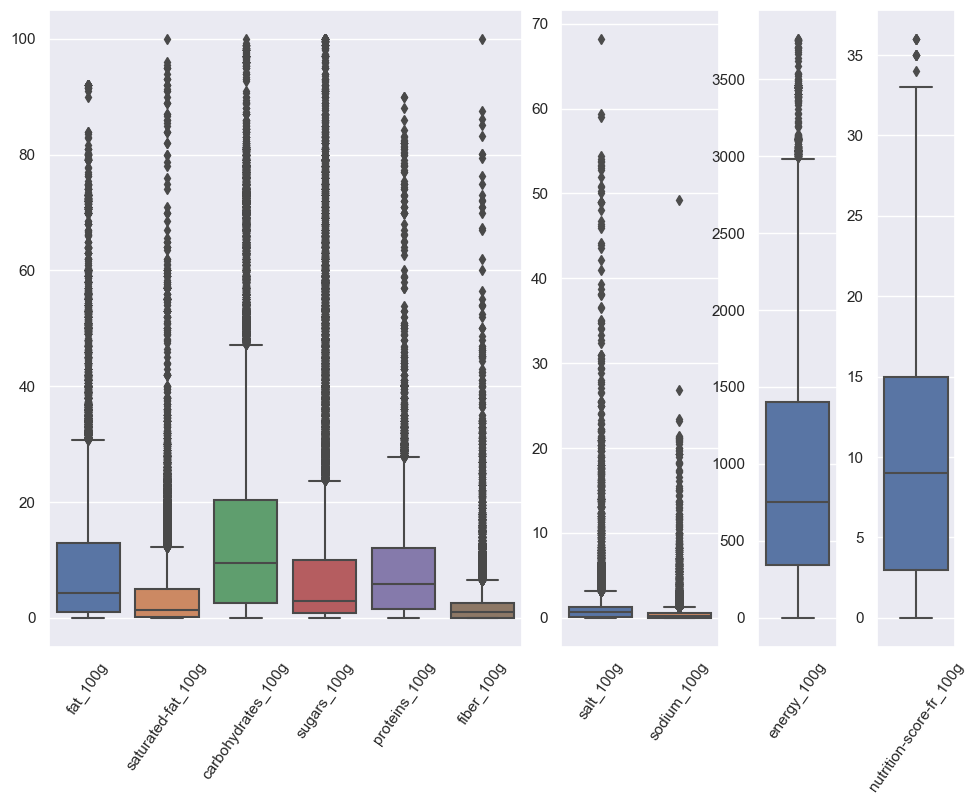

In [19]:
boxplot_nums(sm_df, [macro_nutrients, salt, energy_cols, scores_cols])

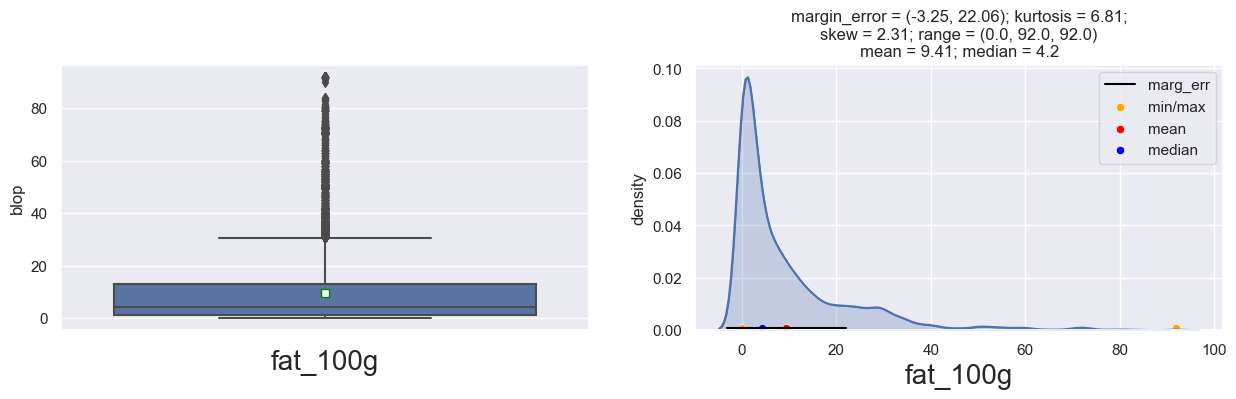

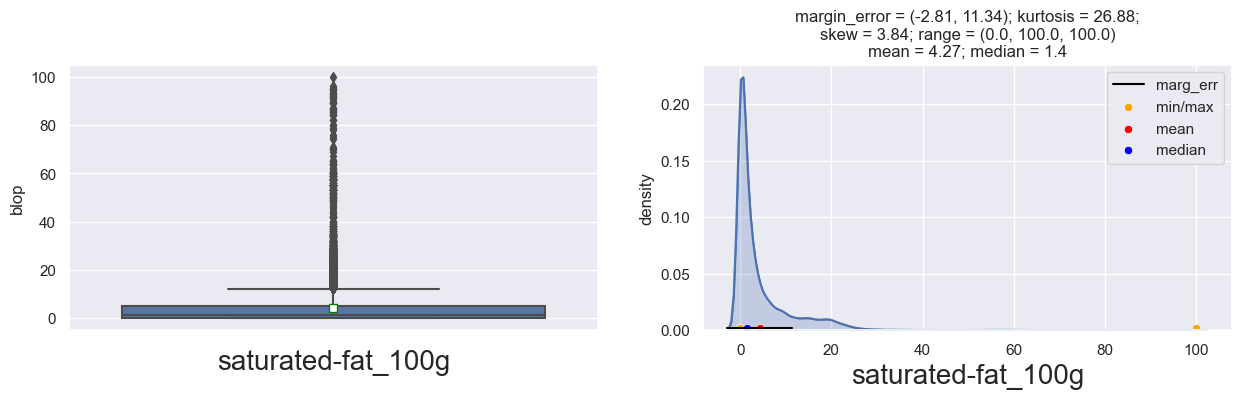

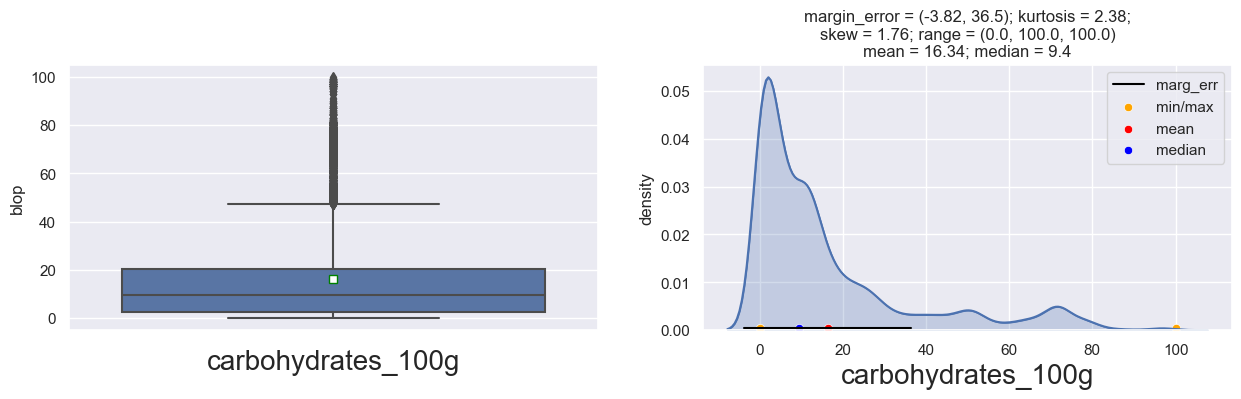

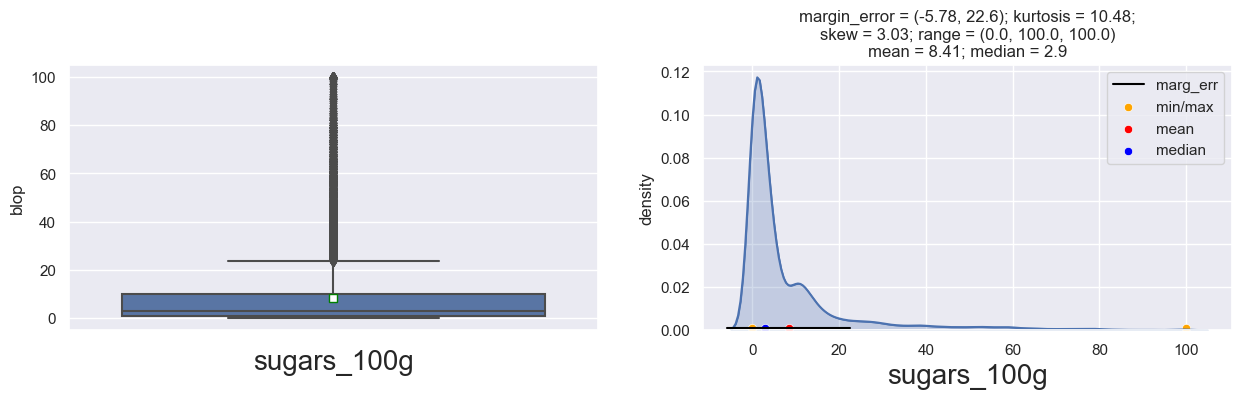

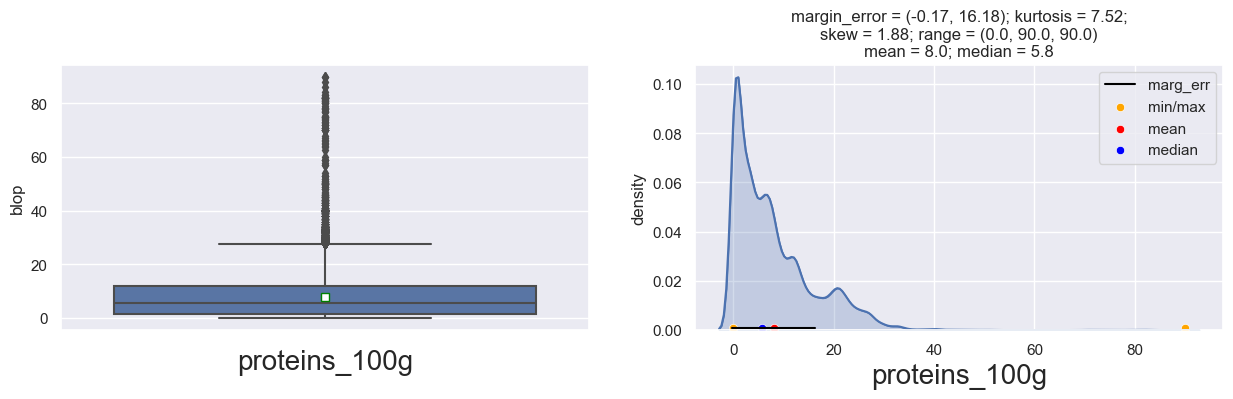

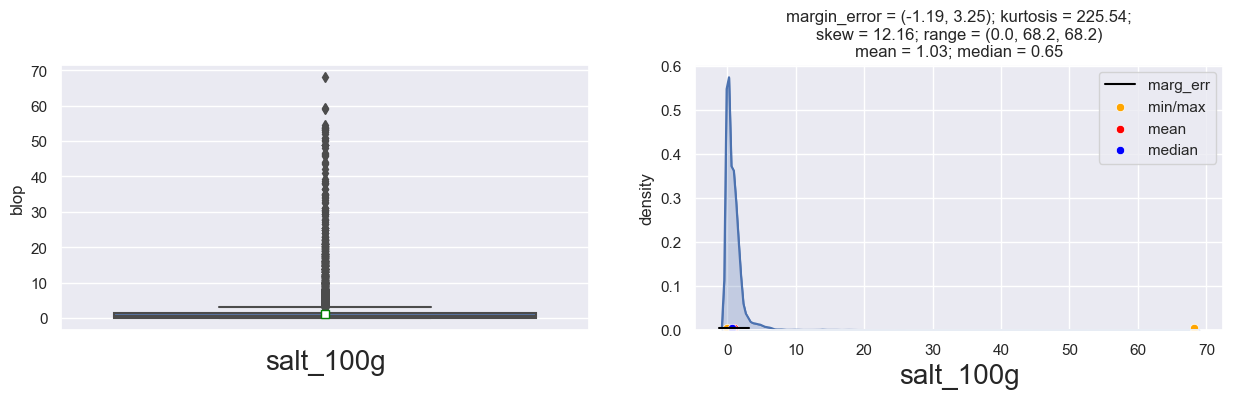

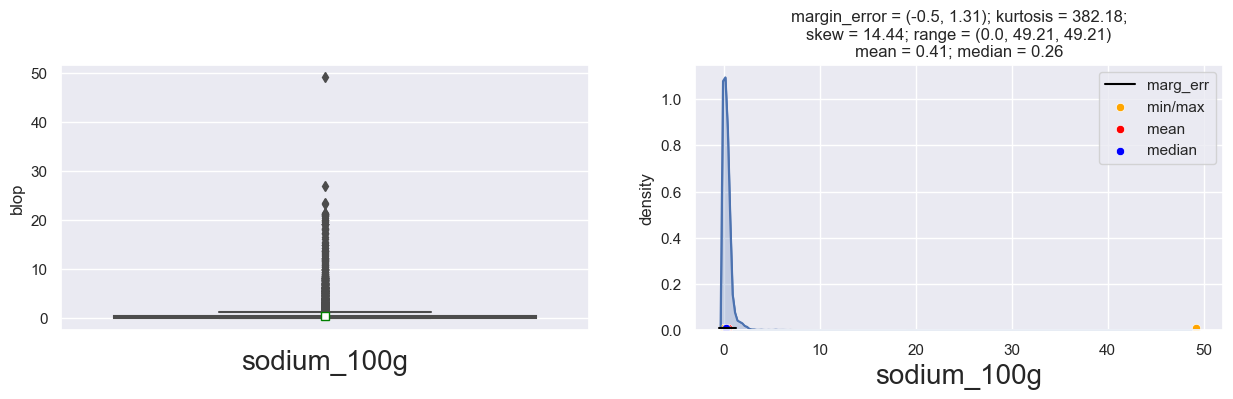

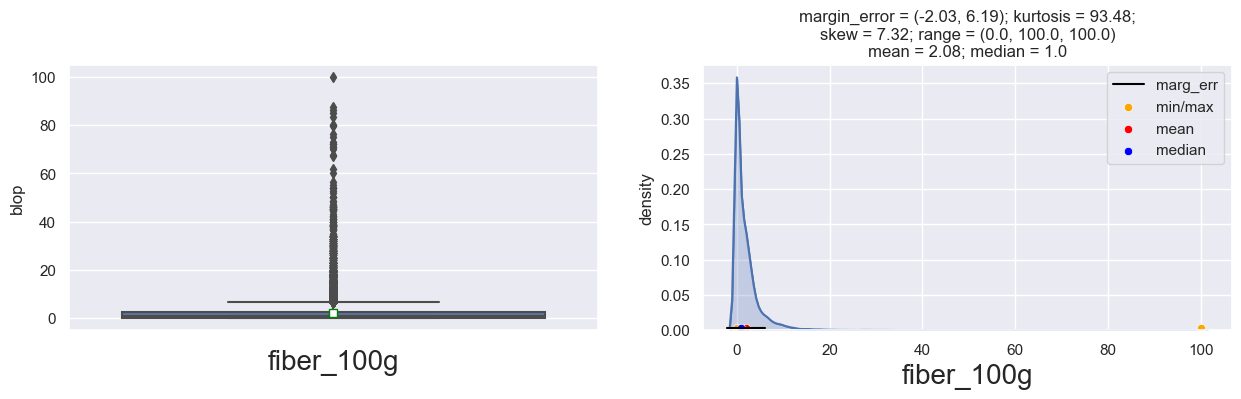

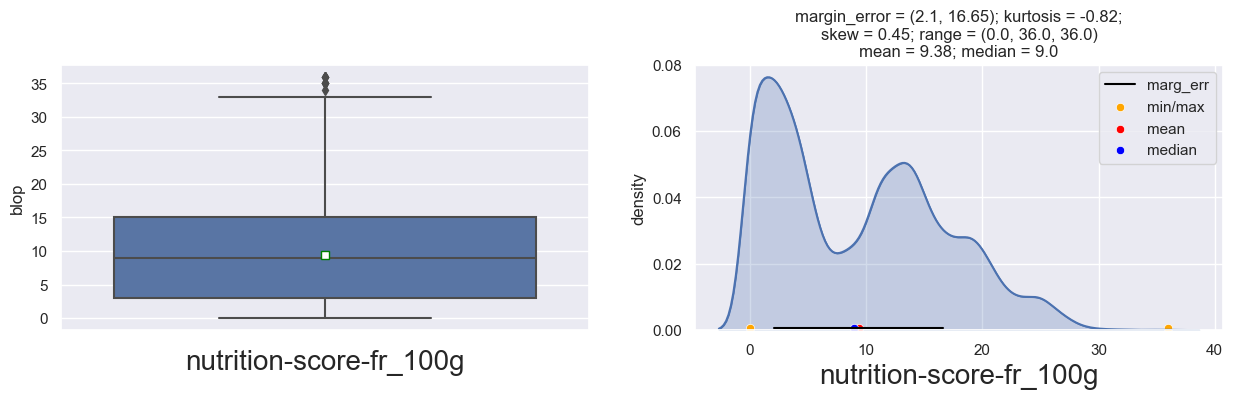

In [20]:
UVA_num_plus(sm_df, sm_num_cols)

In [21]:
## initial (2 282 517, 186)

sm_df.shape

(46254, 15)

In [22]:
#sm_df.isna().sum()

In [23]:
show_nulls(sm_df)

                         count  null_percent
pnns_groups_1            18508     40.013837
pnns_groups_2            18420     39.823583
carbohydrates_100g       16890     36.515761
fat_100g                 16844     36.416310
fiber_100g               11737     25.375103
nutrition-score-fr_100g   9458     20.447961
energy_100g                239      0.516712
sugars_100g                 70      0.151338
salt_100g                   68      0.147014
saturated-fat_100g          68      0.147014
proteins_100g               67      0.144852
sodium_100g                 67      0.144852
code                         0      0.000000
nutrition_grade_fr           0      0.000000
product_name                 0      0.000000


### Distribution avec retrait des éléments sans pnns_groups_1

In [24]:
df_only_pnns_avaliable = pd.DataFrame(sm_df.loc[sm_df['pnns_groups_1'].isna() == False]).copy()
df_only_pnns_avaliable.shape

(27746, 15)

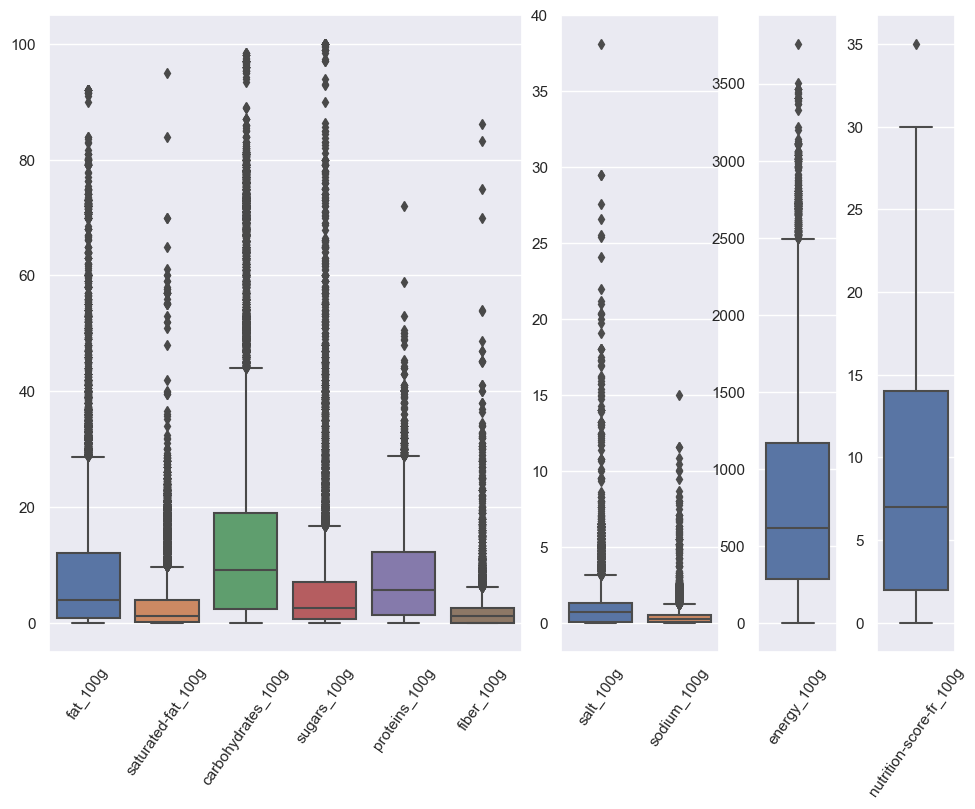

In [25]:
boxplot_nums(df_only_pnns_avaliable, [macro_nutrients, salt, energy_cols, scores_cols])

In [26]:
# check inverse : uniquement valeurs avec pnns_groups_1 manquants

In [27]:
df_only_pnns_missing = pd.DataFrame(sm_df.loc[sm_df['pnns_groups_1'].isna() == True]).copy()
df_only_pnns_missing.shape

(18508, 15)

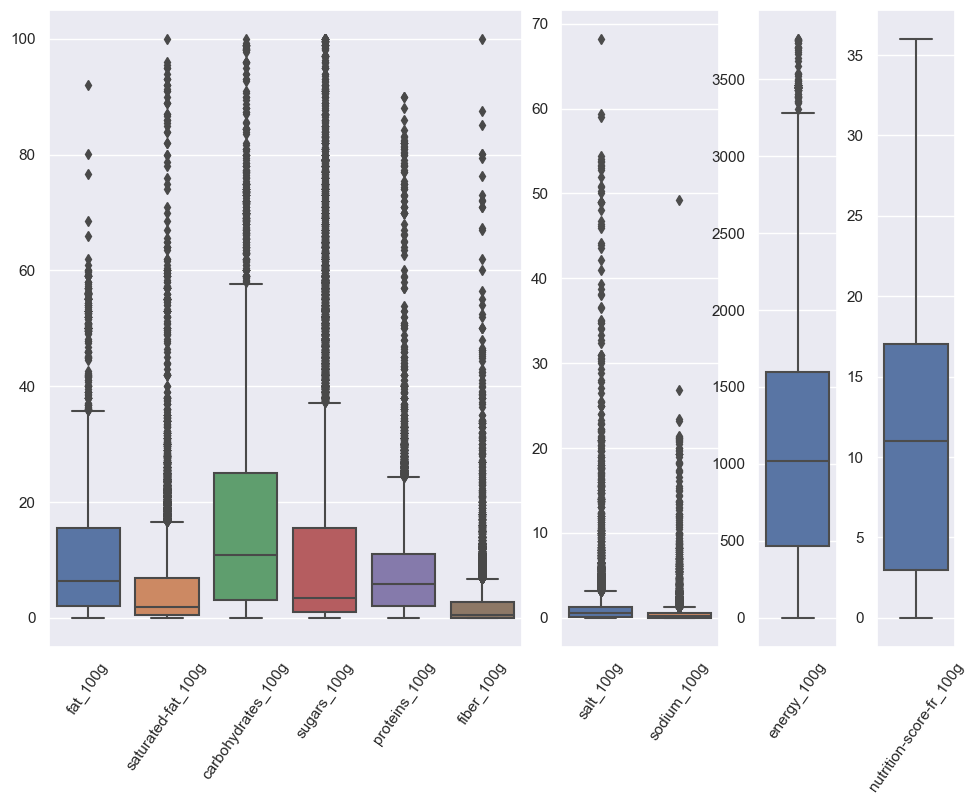

In [28]:
boxplot_nums(df_only_pnns_missing, [macro_nutrients, salt, energy_cols, scores_cols])

### Distribution avec retrait d'outliers

In [29]:
skewed_num_cols = macro_nutrients + salt + energy_cols
skewed_num_cols

['fat_100g',
 'saturated-fat_100g',
 'carbohydrates_100g',
 'sugars_100g',
 'proteins_100g',
 'fiber_100g',
 'salt_100g',
 'sodium_100g',
 'energy_100g']

In [30]:
sm_df.shape

(46254, 15)

In [31]:
q1 = sm_df[skewed_num_cols].quantile(0.25)
q3 = sm_df[skewed_num_cols].quantile(0.75)
iqr = q3 - q1

treshold = 1.5
out_low = q1 - treshold * iqr
out_high = q3 + treshold * iqr

# identify outliers at low and high range : 
np.sum((sm_df.loc[:, skewed_num_cols] > out_high) | (sm_df.loc[:, skewed_num_cols] < out_low))

fat_100g              1933
saturated-fat_100g    5295
carbohydrates_100g    3183
sugars_100g           4521
proteins_100g          924
fiber_100g            2371
salt_100g             2271
sodium_100g           2274
energy_100g            291
dtype: int64

In [32]:
outliers = ((sm_df.loc[:, skewed_num_cols] > out_high) | (sm_df.loc[:, skewed_num_cols] < out_low)).any(axis=1)

df_no_outliers = sm_df.loc[~outliers, :]
df_no_outliers.shape

(30263, 15)

In [33]:
sm_df.loc[:, skewed_num_cols]

,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,fiber_100g,salt_100g,sodium_100g,energy_100g
0,NaN,0.80,NaN,87.70,0.600,0.90,0.0100,0.003937,1753.0
1,NaN,2.90,NaN,50.30,9.500,3.90,0.0030,0.001181,2406.0
2,0.0,0.00,10.40,10.40,0.000,0.00,0.0254,0.010000,177.0
3,NaN,11.00,NaN,1.00,7.500,1.40,0.8000,0.314961,1079.0
4,0.0,0.00,10.40,10.40,0.000,NaN,0.1000,0.039370,177.0
...,...,...,...,...,...,...,...,...,...
46249,1.3,1.28,95.31,0.10,0.004,1.47,0.0010,0.000394,1031.0
46250,NaN,12.00,NaN,10.50,8.700,0.00,0.2900,0.114173,1084.0
46251,NaN,1.00,NaN,1.00,10.000,10.00,10.0000,3.937008,4.0
46252,NaN,3.73,NaN,3.89,21.220,12.20,0.1000,0.039370,2406.0


In [34]:
out_high

fat_100g                30.750000
saturated-fat_100g      12.200000
carbohydrates_100g      47.250000
sugars_100g             23.800000
proteins_100g           27.750000
fiber_100g               6.500000
salt_100g                3.130000
sodium_100g              1.232283
energy_100g           2989.250000
dtype: float64

In [35]:
outliers

0         True
1         True
2        False
3        False
4        False
         ...  
46249     True
46250    False
46251     True
46252     True
46253    False
Length: 46254, dtype: bool

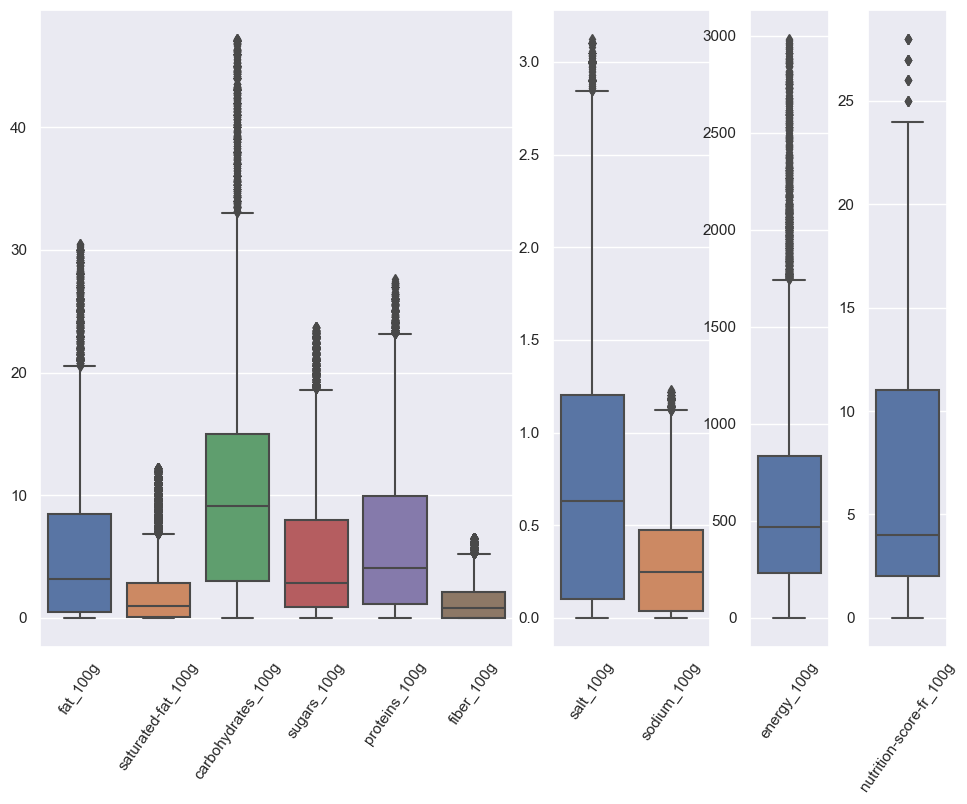

In [36]:
boxplot_nums(df_no_outliers, [macro_nutrients, salt, energy_cols, scores_cols])

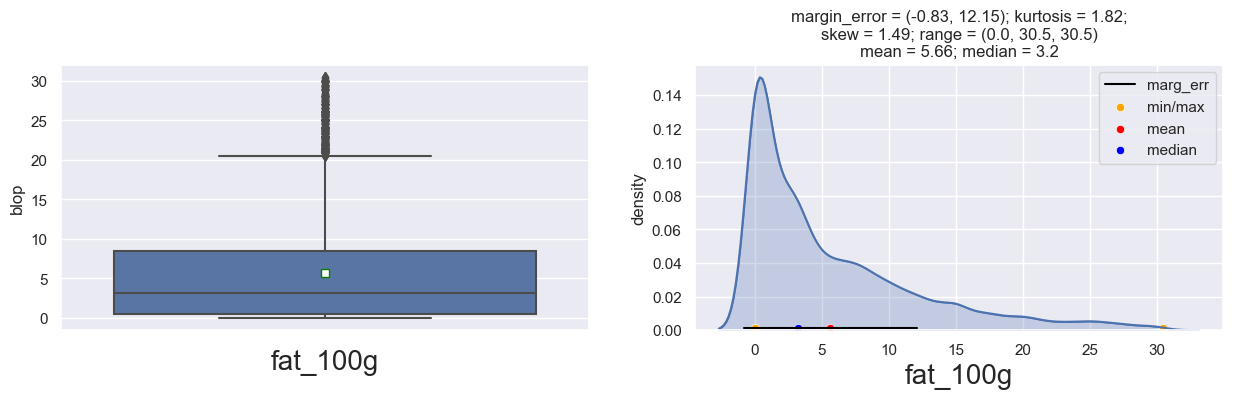

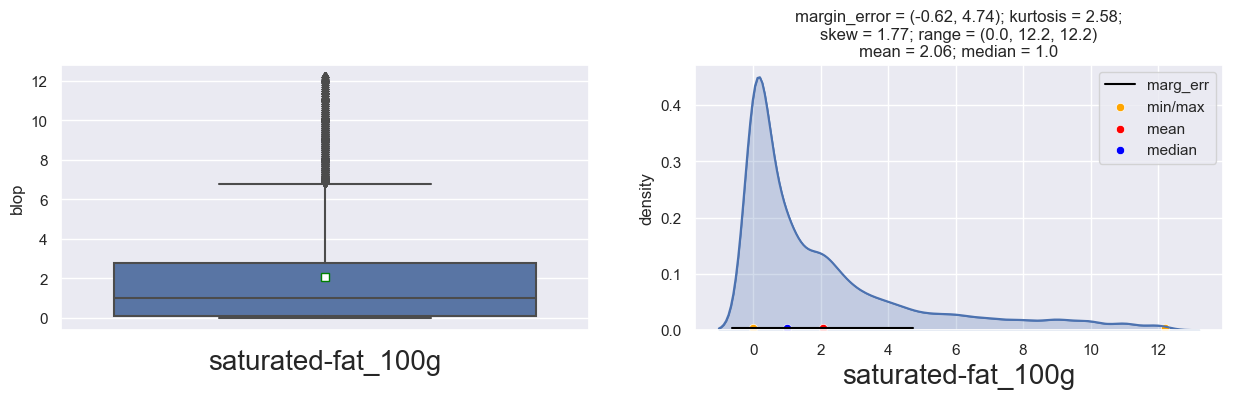

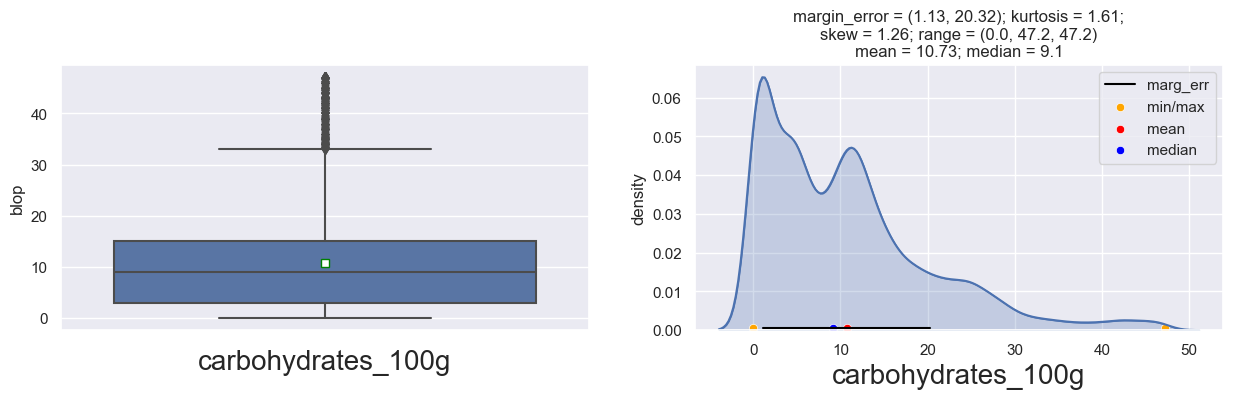

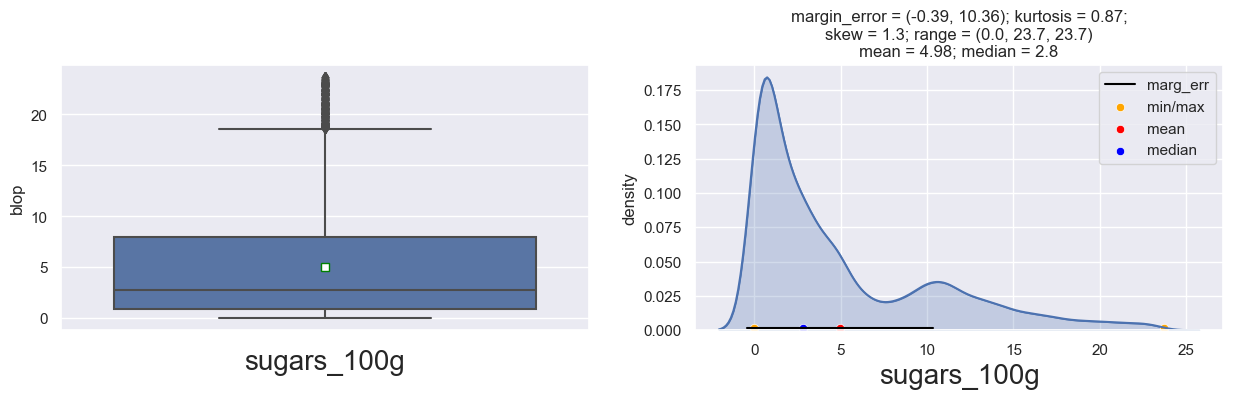

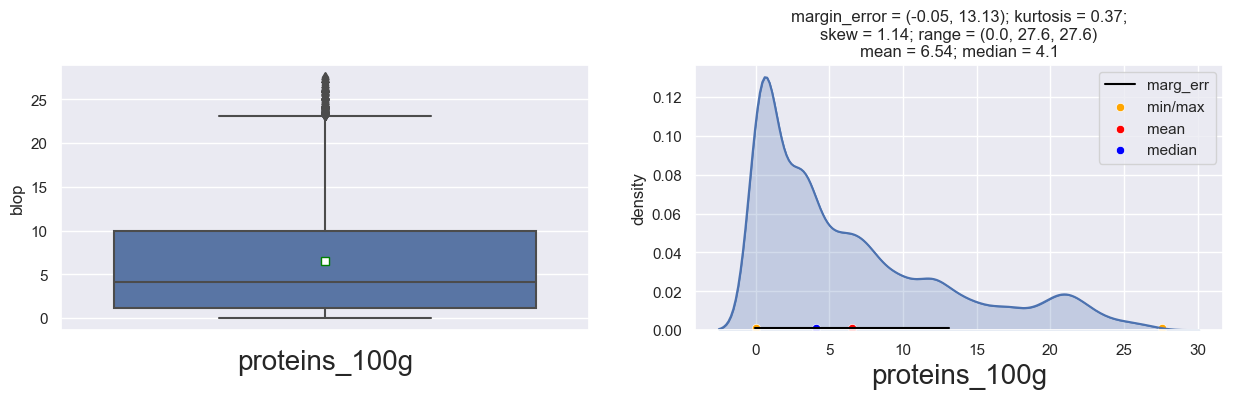

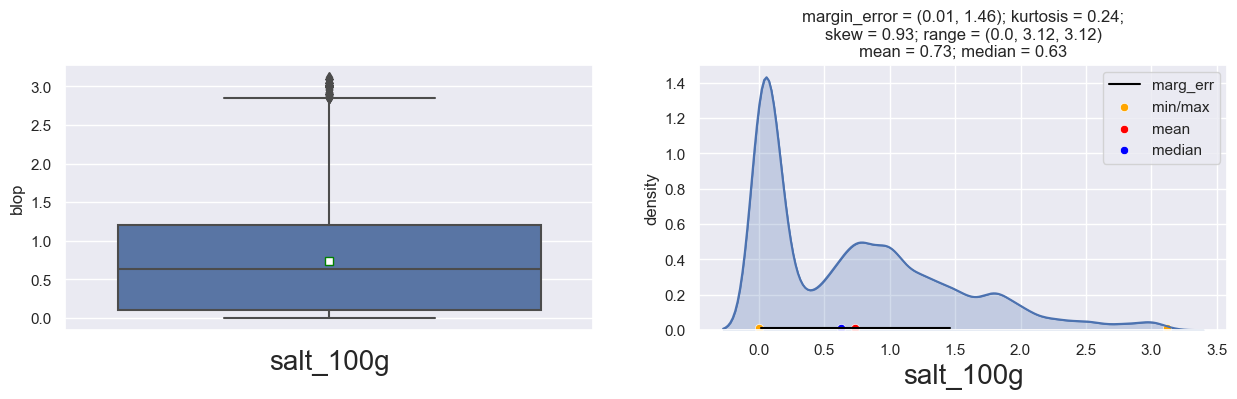

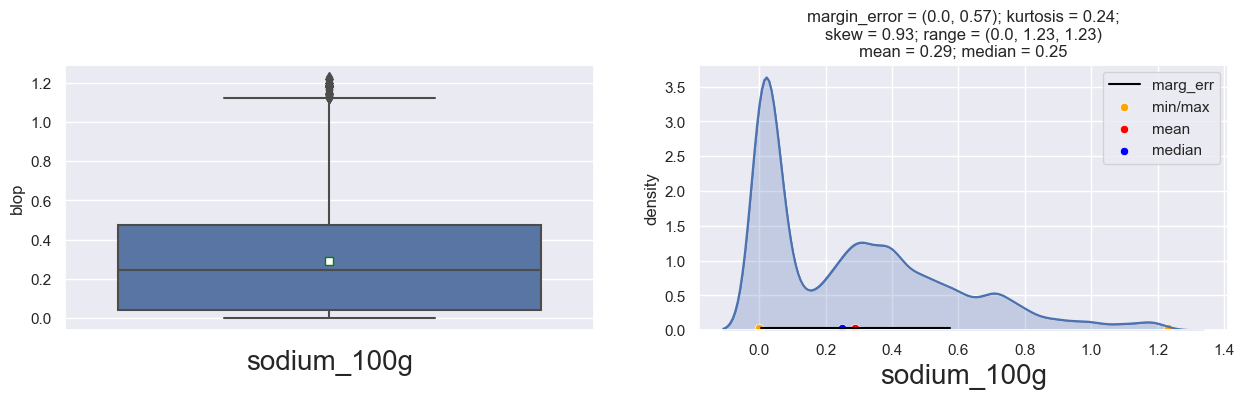

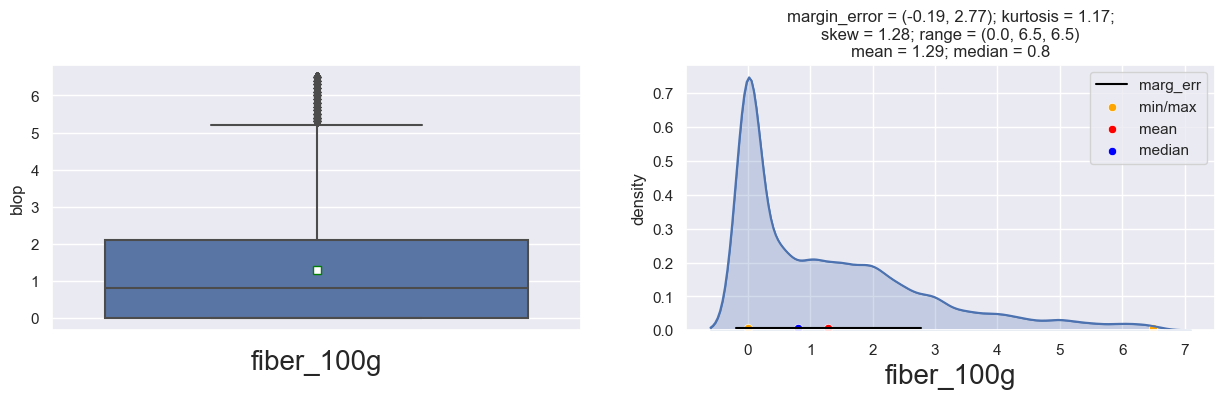

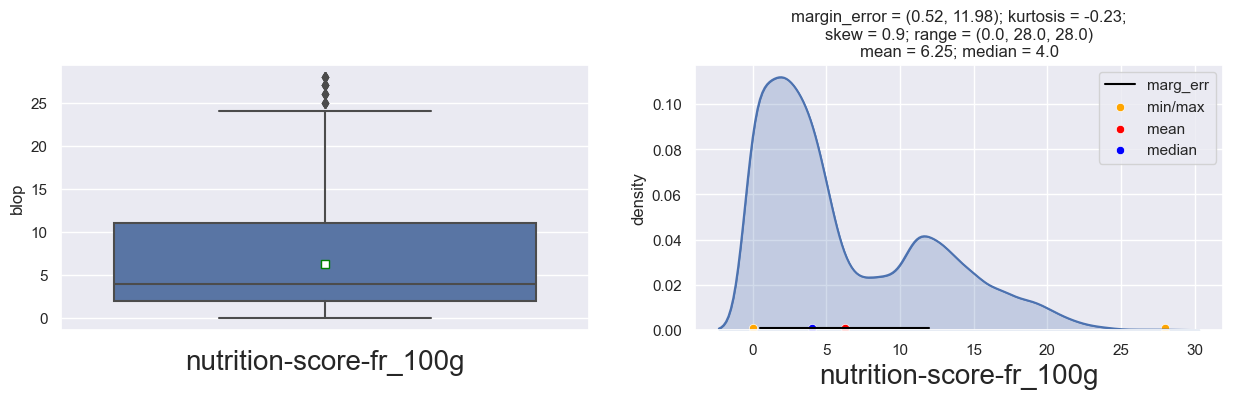

In [37]:
# distribution sans outliers
UVA_num_plus(df_no_outliers, sm_num_cols)

### Distribution avec retrait d'outliers par catégorie pnns_groups_1

In [38]:
df_no_outliers_cat = pd.DataFrame(sm_df).copy()
pnns_list = sm_df['pnns_groups_1'].dropna().unique().tolist()

q1 = sm_df.groupby(by='pnns_groups_1')[skewed_num_cols].quantile(0.25)
q3 = sm_df.groupby(by='pnns_groups_1')[skewed_num_cols].quantile(0.75)
iqr = q3 - q1

treshold = 1.5
out_low = q1 - treshold * iqr
out_high = q3 + treshold * iqr

In [39]:
# identify outliers at low and high range : 
# np.sum((sm_df.loc[:, column] > out_high) | (sm_df.loc[:, column] < out_low))
for pnn in pnns_list:
    pnn_df = df_no_outliers_cat.loc[sm_df['pnns_groups_1'] == pnn][skewed_num_cols]
    out_high_pnn = out_high.loc[out_high.index == pnn].squeeze()
    out_low_pnn = out_low.loc[out_low.index == pnn].squeeze()
    outliers = ((pnn_df > out_high_pnn) | (pnn_df < out_low_pnn)).any(axis=1)
    outliers_index = outliers[outliers == True].index
    
    df_no_outliers_cat.drop(index = outliers_index, inplace = True)

In [40]:
#df_no_outliers_cat = sm_df

#pnn_df = sm_df.loc[sm_df['pnns_groups_1'] == pnn][skewed_num_cols]
#out_high_pnn = out_high.loc[out_high.index == pnn].squeeze()
#out_low_pnn = out_low.loc[out_low.index == pnn].squeeze()
#outliers = ((pnn_df > out_high_pnn) | (pnn_df < out_low_pnn)).any(axis=1)
#outliers_index = outliers[outliers == True].index
#df_no_outliers_cat.drop(index = outliers_index, inplace = True)

In [41]:
print(f'Shape initiale : {sm_df.shape}')
print(f'Shape après retrait outliers (simple) : {df_no_outliers.shape}')
print(f'Shape après retrait outliers par catégorie : {df_no_outliers_cat.shape}')

Shape initiale : (46254, 15)
Shape après retrait outliers (simple) : (30263, 15)
Shape après retrait outliers par catégorie : (40432, 15)


In [42]:
sm_df = df_no_outliers_cat.copy()

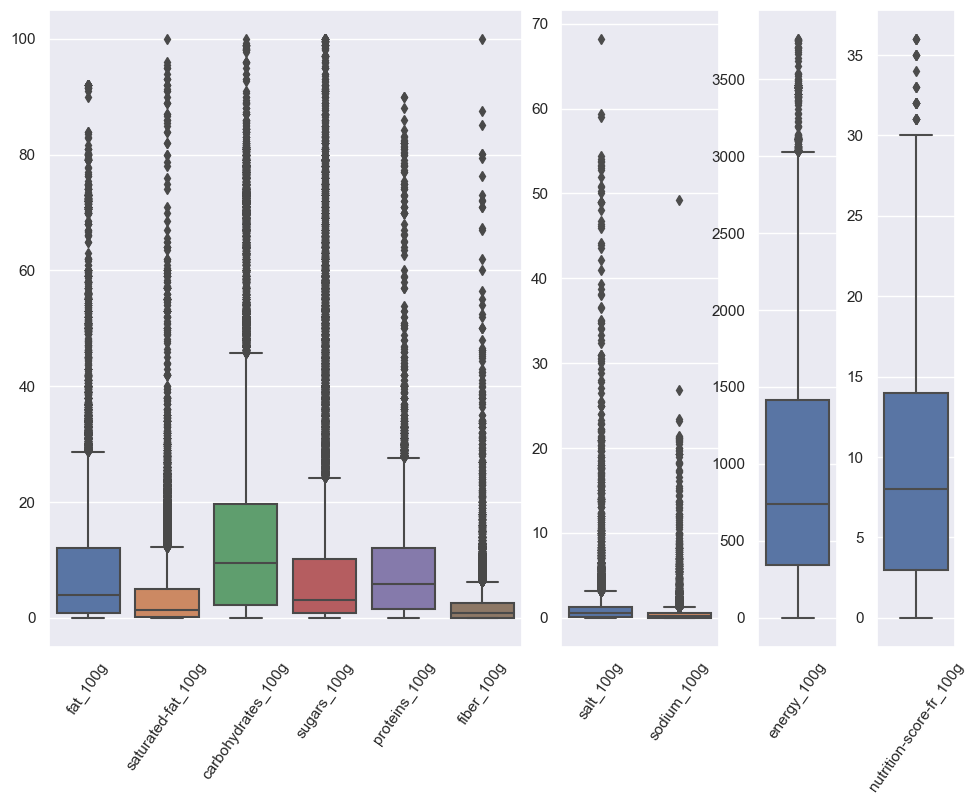

In [43]:
boxplot_nums(df_no_outliers_cat, [macro_nutrients, salt, energy_cols, scores_cols])

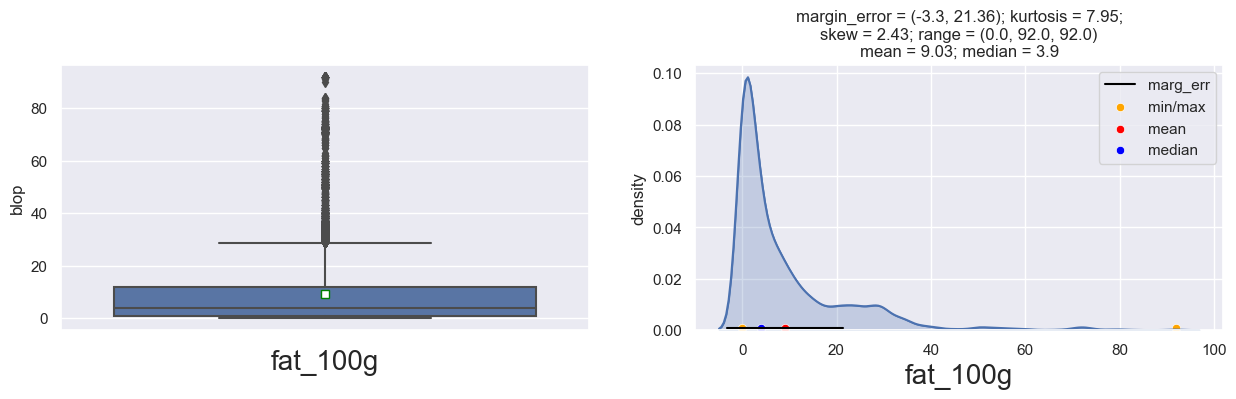

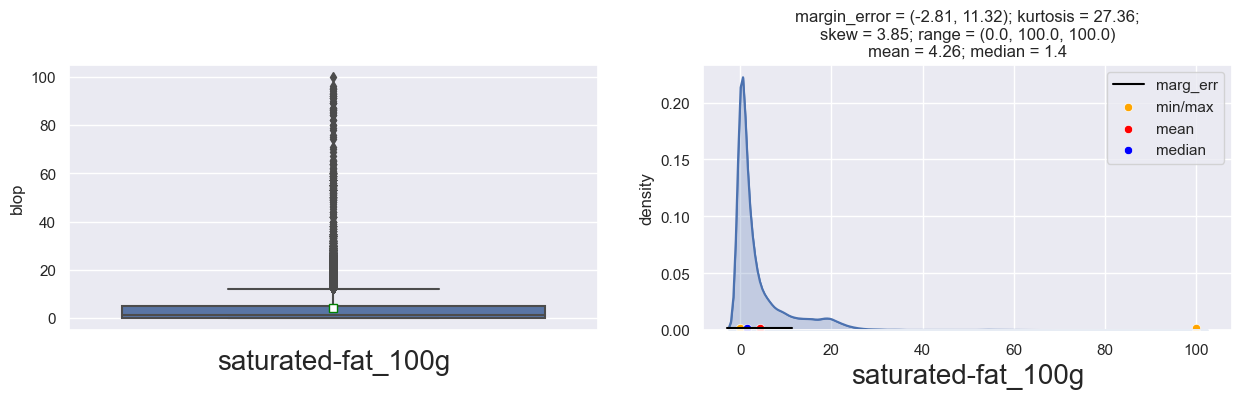

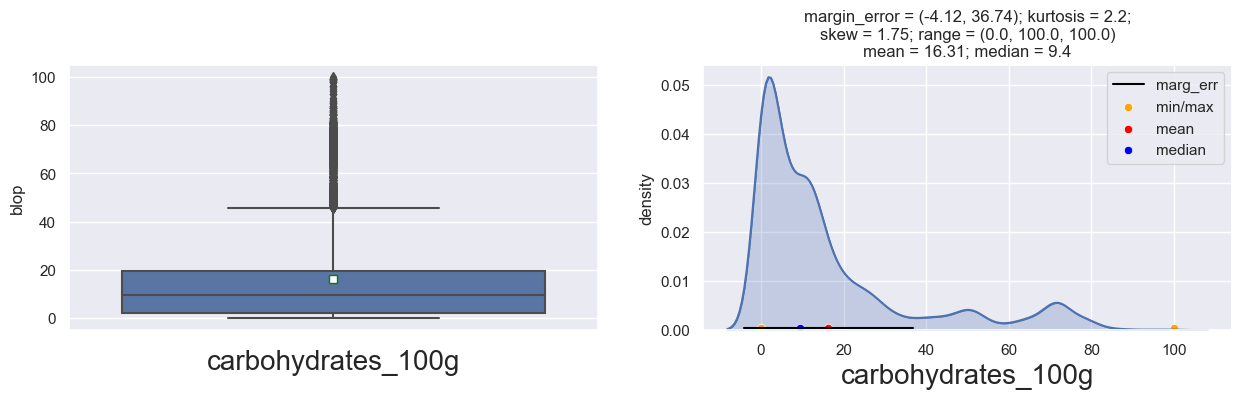

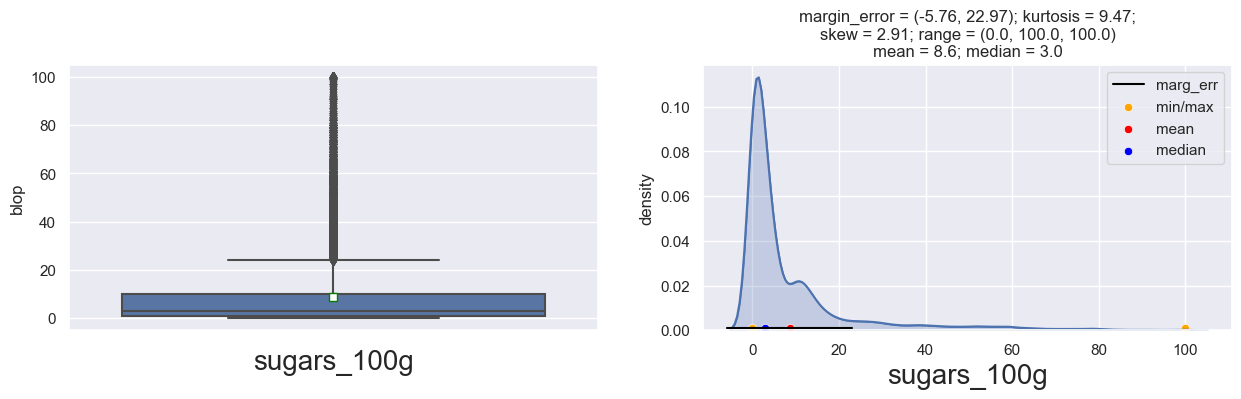

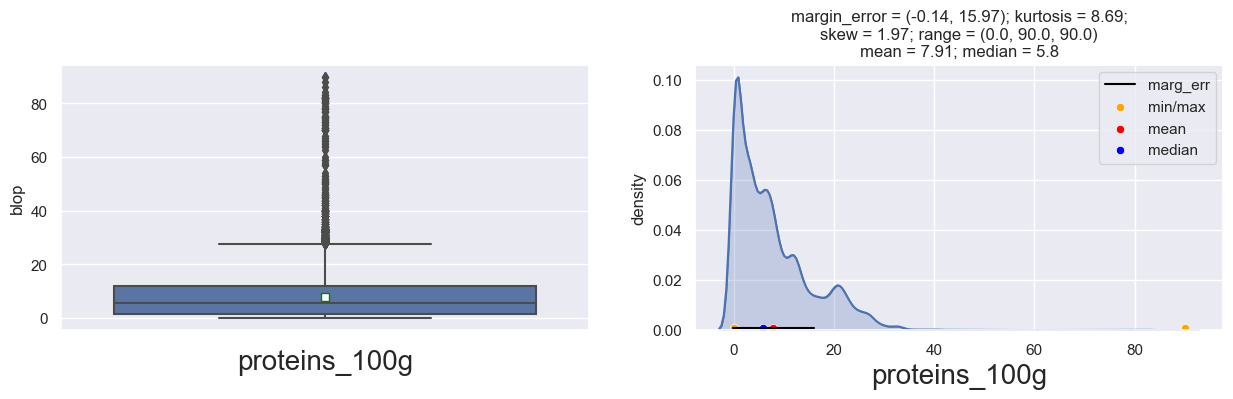

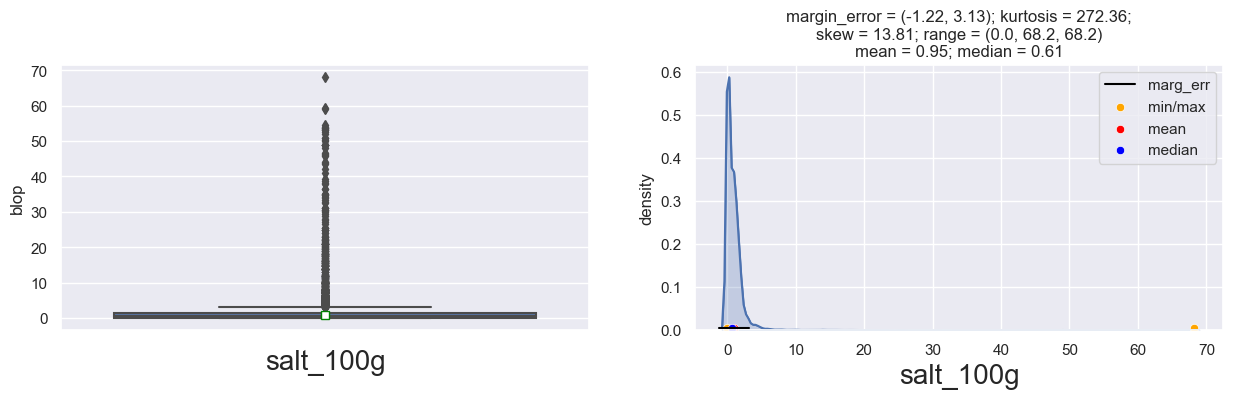

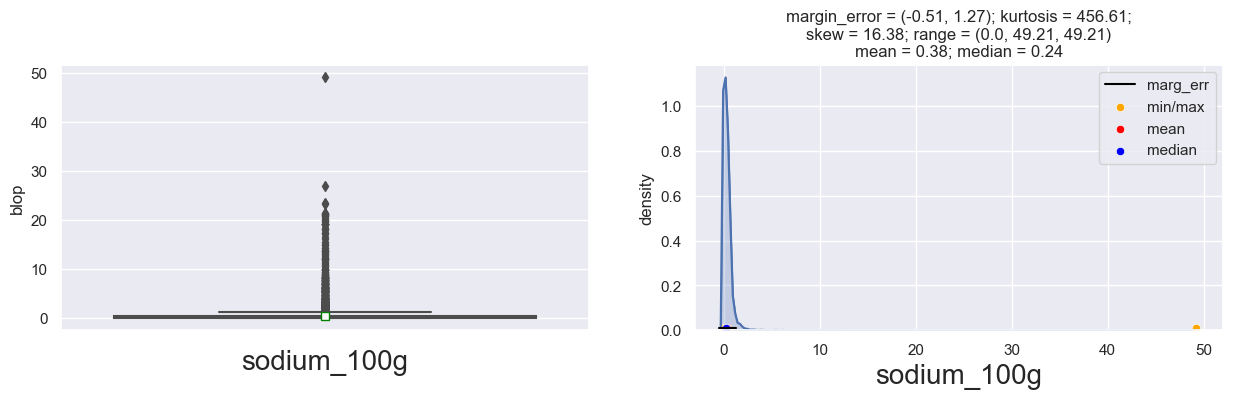

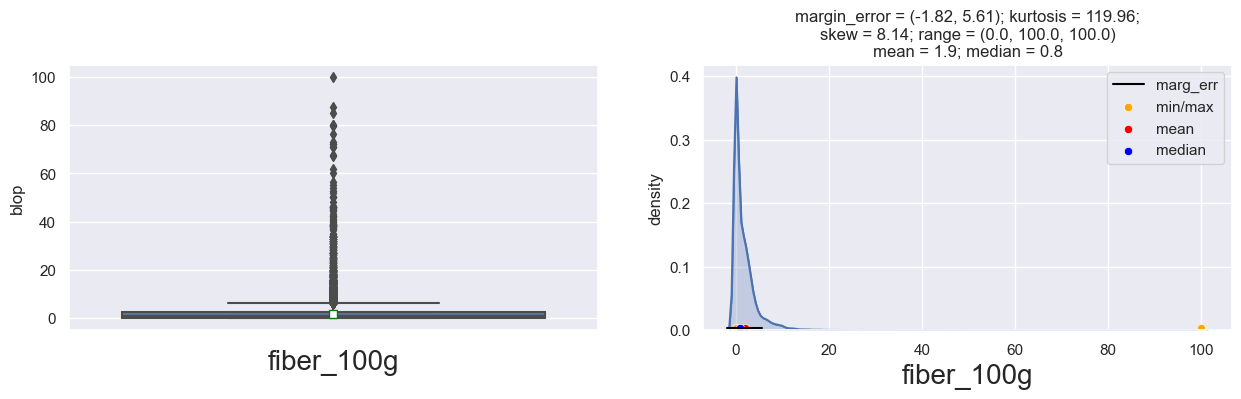

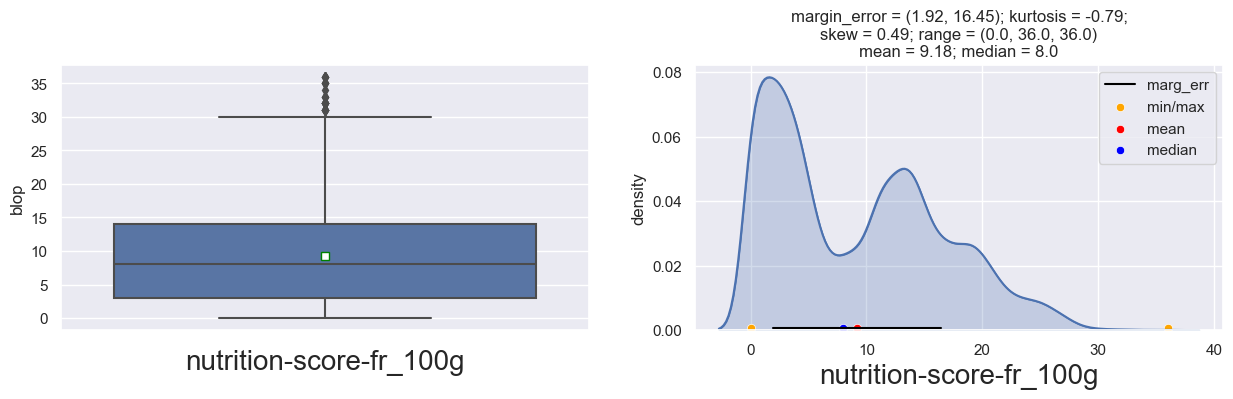

In [44]:
UVA_num_plus(df_no_outliers_cat, sm_num_cols)

## Categories / "unknown"

In [45]:
main_cats = sm_df['pnns_groups_1'].unique()
main_cats

array([nan, 'Beverages', 'Composite foods', 'Fat and sauces',
       'Fruits and vegetables', 'Sugary snacks',
       'Milk and dairy products', 'Cereals and potatoes',
       'Fish Meat Eggs', 'Salty snacks'], dtype=object)

In [46]:
sm_df['pnns_groups_1'].value_counts()

pnns_groups_1
Milk and dairy products    4398
Composite foods            3996
Fish Meat Eggs             3330
Beverages                  2867
Cereals and potatoes       2627
Fruits and vegetables      1988
Fat and sauces             1299
Sugary snacks              1030
Salty snacks                389
Name: count, dtype: int64

In [47]:
all_cats = sm_df['pnns_groups_1'].unique().tolist()
all_cats

[nan,
 'Beverages',
 'Composite foods',
 'Fat and sauces',
 'Fruits and vegetables',
 'Sugary snacks',
 'Milk and dairy products',
 'Cereals and potatoes',
 'Fish Meat Eggs',
 'Salty snacks']

In [48]:
all_cols = sm_df.columns
all_cols

Index(['code', 'nutrition_grade_fr', 'nutrition-score-fr_100g',
       'proteins_100g', 'energy_100g', 'salt_100g', 'sodium_100g',
       'sugars_100g', 'saturated-fat_100g', 'product_name', 'fiber_100g',
       'fat_100g', 'carbohydrates_100g', 'pnns_groups_2', 'pnns_groups_1'],
      dtype='object')

In [49]:
main_cats = ['fat_100g', 'salt_100g']
complementary_cats = ['saturated-fat_100g','sodium_100g']

In [50]:
final_cats = [c for c in all_cols if c not in main_cats+complementary_cats]
final_cats

['code',
 'nutrition_grade_fr',
 'nutrition-score-fr_100g',
 'proteins_100g',
 'energy_100g',
 'sugars_100g',
 'product_name',
 'fiber_100g',
 'carbohydrates_100g',
 'pnns_groups_2',
 'pnns_groups_1']

In [51]:
all_cols

Index(['code', 'nutrition_grade_fr', 'nutrition-score-fr_100g',
       'proteins_100g', 'energy_100g', 'salt_100g', 'sodium_100g',
       'sugars_100g', 'saturated-fat_100g', 'product_name', 'fiber_100g',
       'fat_100g', 'carbohydrates_100g', 'pnns_groups_2', 'pnns_groups_1'],
      dtype='object')

In [52]:
num_cols = sm_df.columns[sm_df.dtypes == 'float64']
num_cols

Index(['nutrition-score-fr_100g', 'proteins_100g', 'energy_100g', 'salt_100g',
       'sodium_100g', 'sugars_100g', 'saturated-fat_100g', 'fiber_100g',
       'fat_100g', 'carbohydrates_100g'],
      dtype='object')

# Inputing

## categories : most frequent

In [53]:
show_nulls(sm_df)

                         count  null_percent
pnns_groups_1            18508     45.775623
pnns_groups_2            18420     45.557974
carbohydrates_100g       16172     39.998021
fat_100g                 16131     39.896617
fiber_100g                9836     24.327266
nutrition-score-fr_100g   8274     20.463989
energy_100g                226      0.558963
sugars_100g                 70      0.173130
salt_100g                   68      0.168184
proteins_100g               67      0.165710
sodium_100g                 67      0.165710
saturated-fat_100g          67      0.165710
code                         0      0.000000
nutrition_grade_fr           0      0.000000
product_name                 0      0.000000


In [54]:
sm_df['pnns_groups_1'].value_counts()

pnns_groups_1
Milk and dairy products    4398
Composite foods            3996
Fish Meat Eggs             3330
Beverages                  2867
Cereals and potatoes       2627
Fruits and vegetables      1988
Fat and sauces             1299
Sugary snacks              1030
Salty snacks                389
Name: count, dtype: int64

In [55]:
sm_df.shape

(40432, 15)

In [56]:
## categorical pnn1 

## inputing valeur vides avec valeur plus fréQUENTE / SIMPLE IMPUTER _ strategy most _frequent
# SimpleImputer(strategy="most_frequent")

In [57]:
sm_df['pnns_groups_1'].value_counts()

pnns_groups_1
Milk and dairy products    4398
Composite foods            3996
Fish Meat Eggs             3330
Beverages                  2867
Cereals and potatoes       2627
Fruits and vegetables      1988
Fat and sauces             1299
Sugary snacks              1030
Salty snacks                389
Name: count, dtype: int64

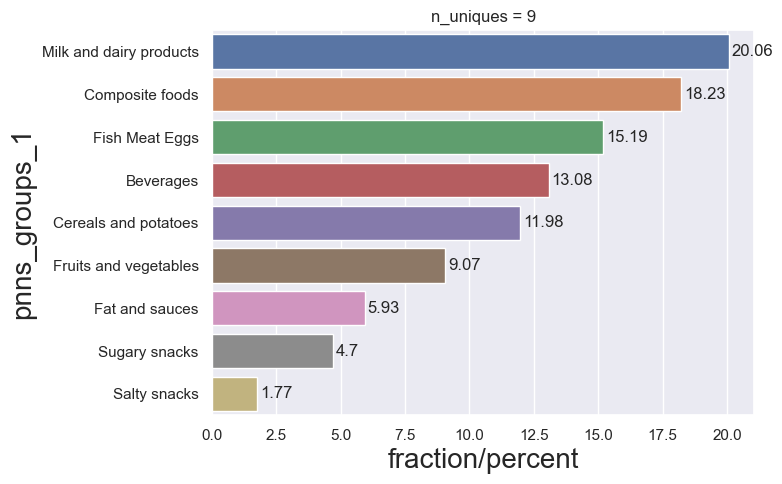

In [58]:
#pd.set_option('display.max_rows', 10)
UVA_category(sm_df, ['pnns_groups_1'])

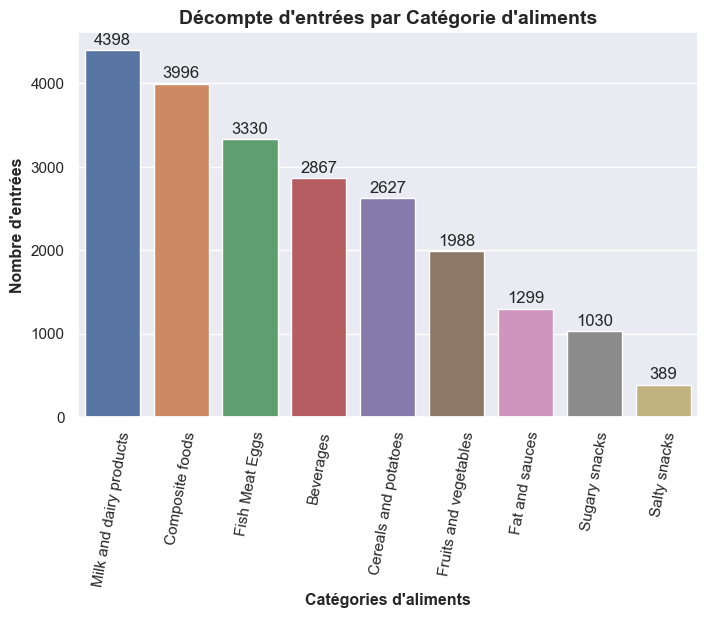

In [59]:
plt.figure(figsize=(8, 5))
plt.xticks(rotation=80)
ax = sns.countplot(data=sm_df
             ,x="pnns_groups_1"
             ,order = sm_df['pnns_groups_1'].value_counts(ascending=False).index
            )
var = ax.bar_label(ax.containers[0], rotation=0, padding=2)
plt.xlabel("Catégories d'aliments", fontsize=11.5, fontweight='bold')
plt.ylabel("Nombre d'entrées", fontsize=11.5, fontweight='bold')
plt.title("Décompte d'entrées par Catégorie d'aliments", fontsize=14, fontweight='bold')
plt.show()

In [60]:
sm_df.shape

(40432, 15)

In [61]:
## categorical pnn1 
## inputing valeur vides avec valeur plus fréQUENTE / SIMPLE IMPUTER _ strategy most _frequent

In [62]:
#imp_fre = SimpleImputer(missing_values=np.nan, strategy= 'most_frequent')
#imp_pnns = imp_fre.fit_transform(sm_df[['pnns_groups_1', 'pnns_groups_2']])

#sm_df[['pnns_groups_1', 'pnns_groups_2']] = imp_pnns

In [63]:
# "most_frequent" risque de polluer la catégorie choisie... si pas de KNN Imputer => fillna 'Other' 
cat_groups = ['pnns_groups_1', 'pnns_groups_2']
#sm_df[cat_groups].fillna('Other')
sm_df[cat_groups] = sm_df[cat_groups].transform(lambda x: x.fillna('Other'))

In [64]:
show_nulls(sm_df)

                         count  null_percent
carbohydrates_100g       16172     39.998021
fat_100g                 16131     39.896617
fiber_100g                9836     24.327266
nutrition-score-fr_100g   8274     20.463989
energy_100g                226      0.558963
sugars_100g                 70      0.173130
salt_100g                   68      0.168184
proteins_100g               67      0.165710
sodium_100g                 67      0.165710
saturated-fat_100g          67      0.165710
code                         0      0.000000
nutrition_grade_fr           0      0.000000
product_name                 0      0.000000
pnns_groups_2                0      0.000000
pnns_groups_1                0      0.000000


In [65]:
sm_df[['pnns_groups_1', 'pnns_groups_2']].head()

,pnns_groups_1,pnns_groups_2
0,Other,Other
1,Other,Other
2,Beverages,Sweetened beverages
3,Other,Other
5,Other,Other


In [66]:
sm_df['pnns_groups_1'].value_counts()

pnns_groups_1
Other                      18508
Milk and dairy products     4398
Composite foods             3996
Fish Meat Eggs              3330
Beverages                   2867
Cereals and potatoes        2627
Fruits and vegetables       1988
Fat and sauces              1299
Sugary snacks               1030
Salty snacks                 389
Name: count, dtype: int64

In [67]:
sm_df[['pnns_groups_1', 'pnns_groups_2']].value_counts()

pnns_groups_1            pnns_groups_2                   
Other                    Other                               18420
Composite foods          One-dish meals                       3249
Milk and dairy products  Cheese                               1970
Cereals and potatoes     Cereals                              1821
Milk and dairy products  Milk and yogurt                      1595
Fish Meat Eggs           Processed meat                       1535
Fat and sauces           Dressings and sauces                 1213
Fish Meat Eggs           Fish and seafood                     1140
Beverages                Fruit juices                         1106
Fruits and vegetables    Vegetables                            815
                         Fruits                                777
Beverages                Sweetened beverages                   762
                         Non-sugared beverages                 639
Cereals and potatoes     Bread                                 559
Fish

## numerical values

In [68]:
### appliquer imputer différentes strategies (check distribution) avec un groupby categories
### iterative imputer / estimation du choix d'imputer selon la distribution (mean/median/most frequent...)


In [69]:
# Use mean imputation if variables are normally distributed and median imputation otherwise. 
# Mean and median imputation may distort 
# the distribution of the original variables if there is a high percentage of missing data.

In [70]:
sm_num_cols

['fat_100g',
 'saturated-fat_100g',
 'carbohydrates_100g',
 'sugars_100g',
 'proteins_100g',
 'salt_100g',
 'sodium_100g',
 'fiber_100g',
 'nutrition-score-fr_100g']

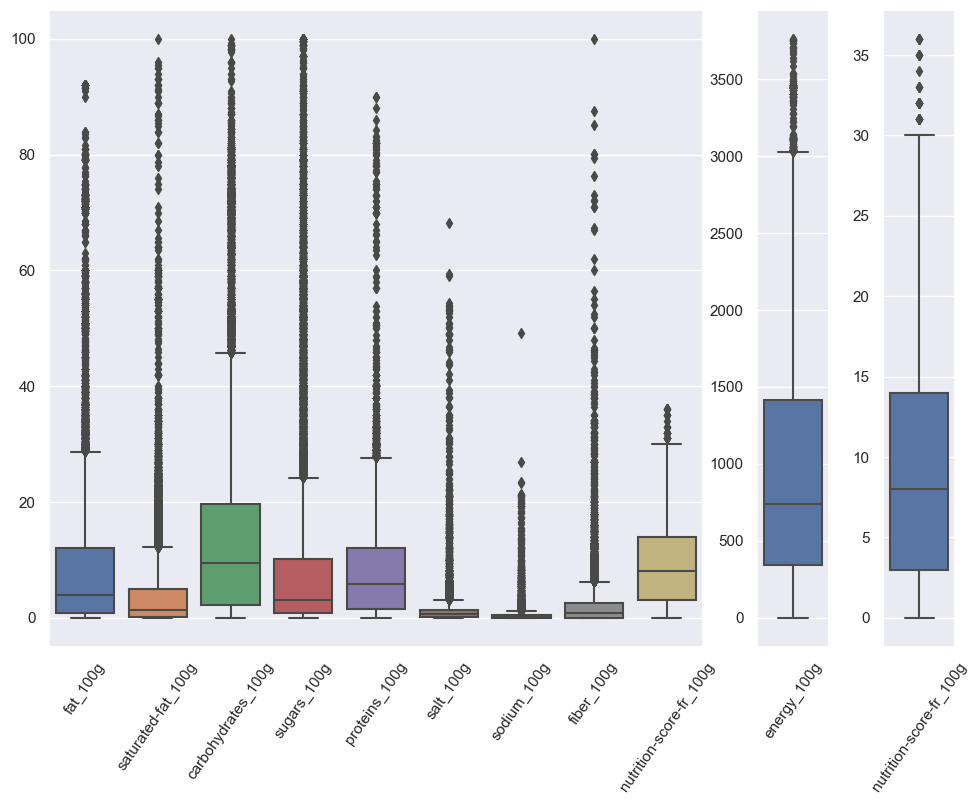

In [71]:
boxplot_nums(sm_df, [sm_num_cols, energy_cols, scores_cols])

### Distribution par catégorie, extraits :

In [72]:
pnns_1_list = sm_df['pnns_groups_1'].dropna().unique().tolist()

In [73]:
pnns_1_list

['Other',
 'Beverages',
 'Composite foods',
 'Fat and sauces',
 'Fruits and vegetables',
 'Sugary snacks',
 'Milk and dairy products',
 'Cereals and potatoes',
 'Fish Meat Eggs',
 'Salty snacks']

In [74]:
num_cols = sm_df.columns[sm_df.dtypes == 'float64']
num_cols

Index(['nutrition-score-fr_100g', 'proteins_100g', 'energy_100g', 'salt_100g',
       'sodium_100g', 'sugars_100g', 'saturated-fat_100g', 'fiber_100g',
       'fat_100g', 'carbohydrates_100g'],
      dtype='object')

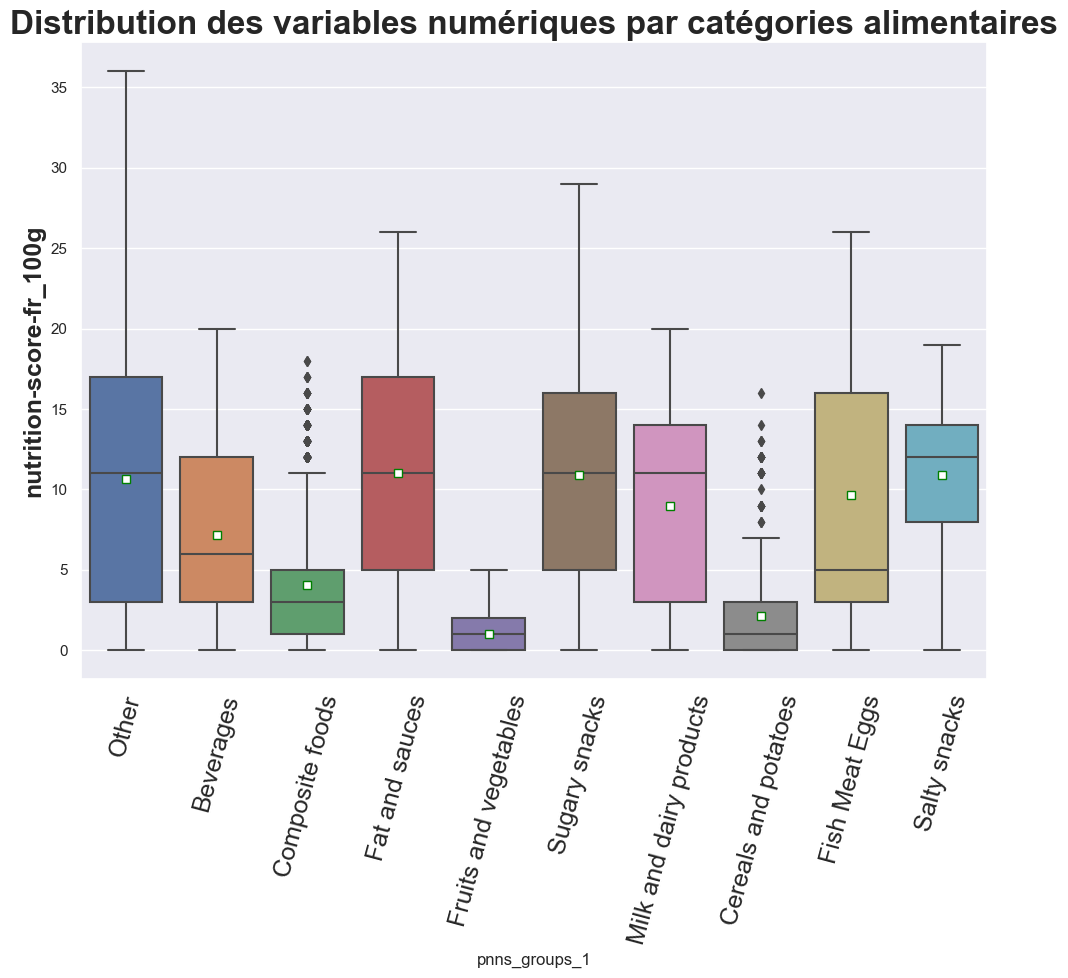

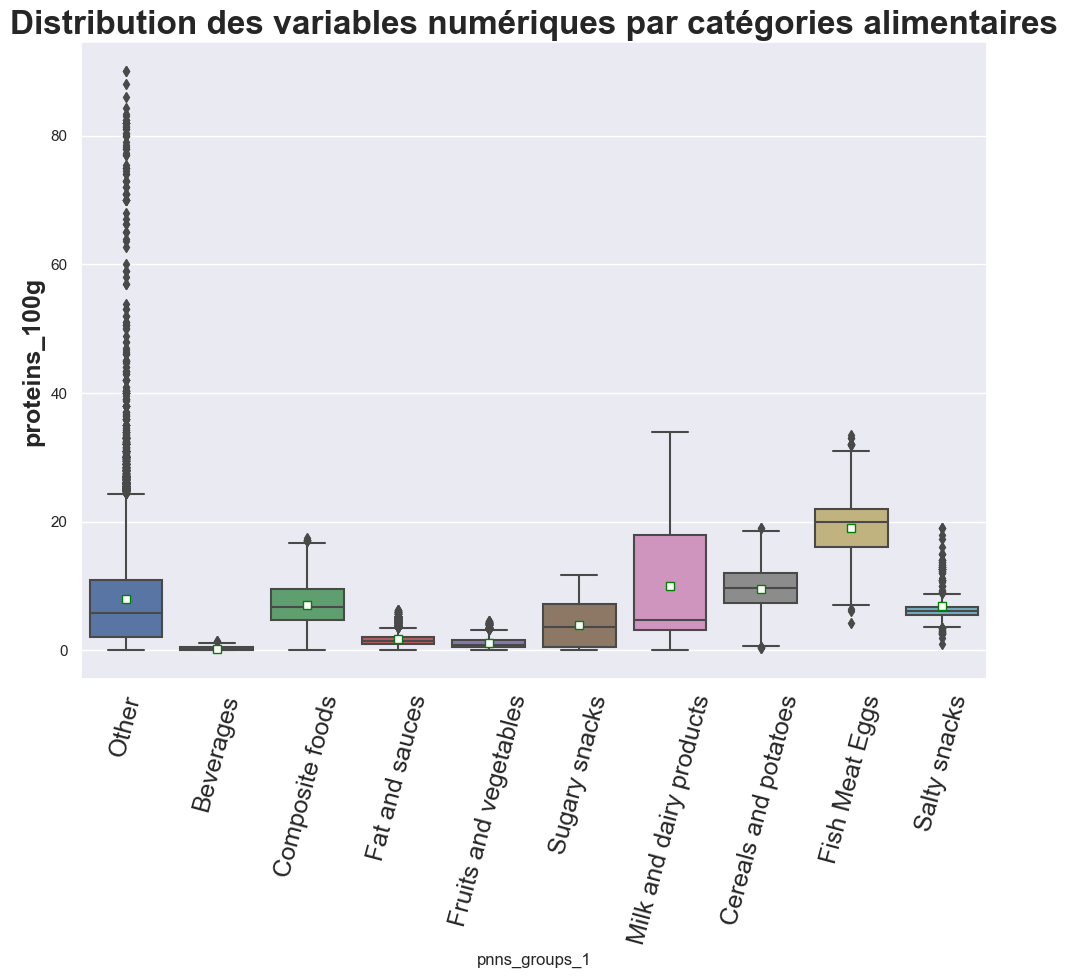

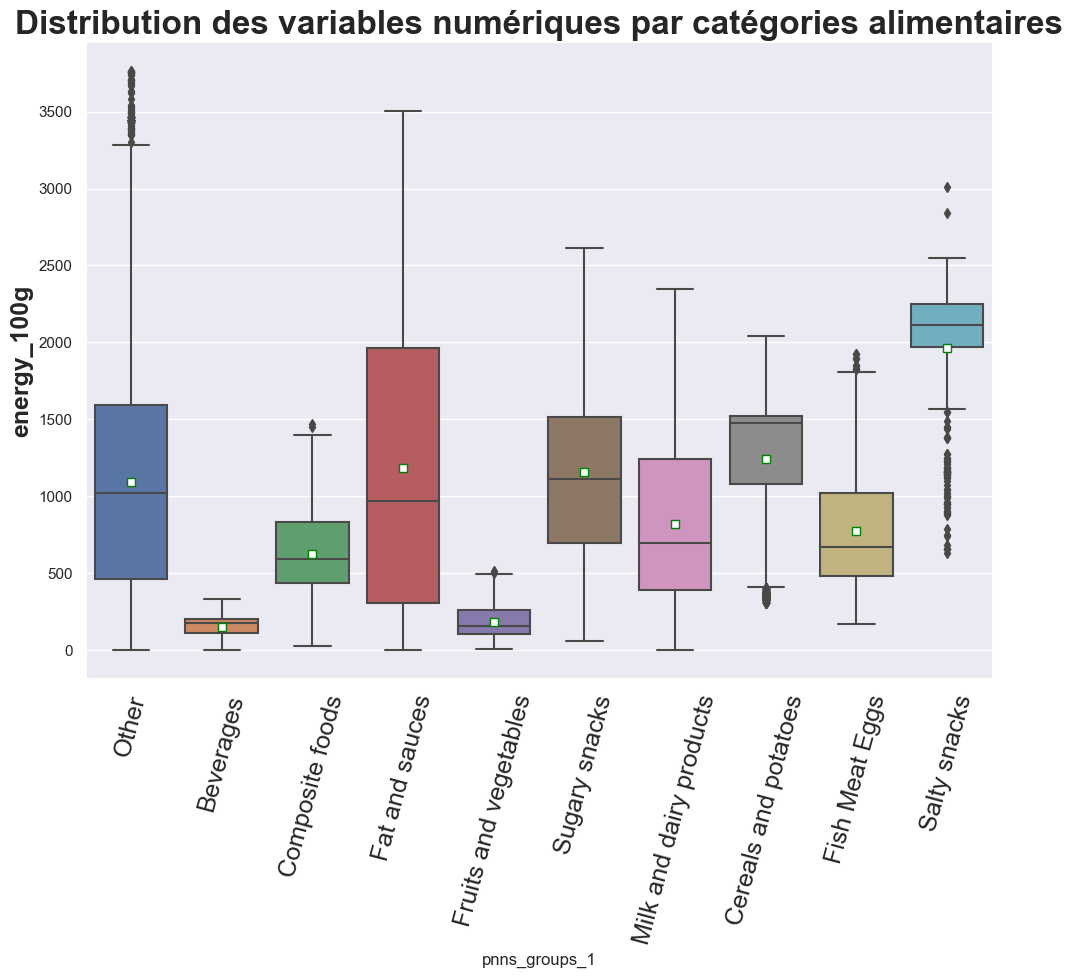

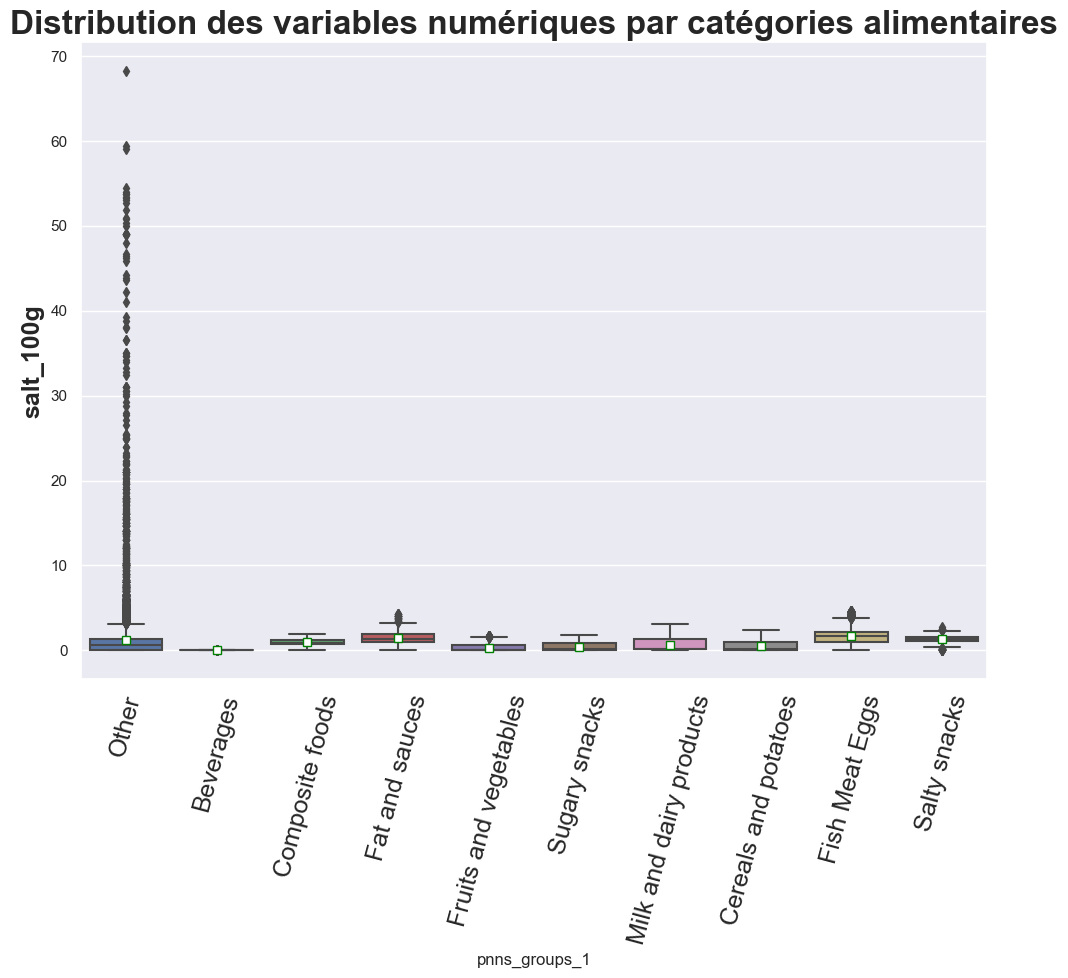

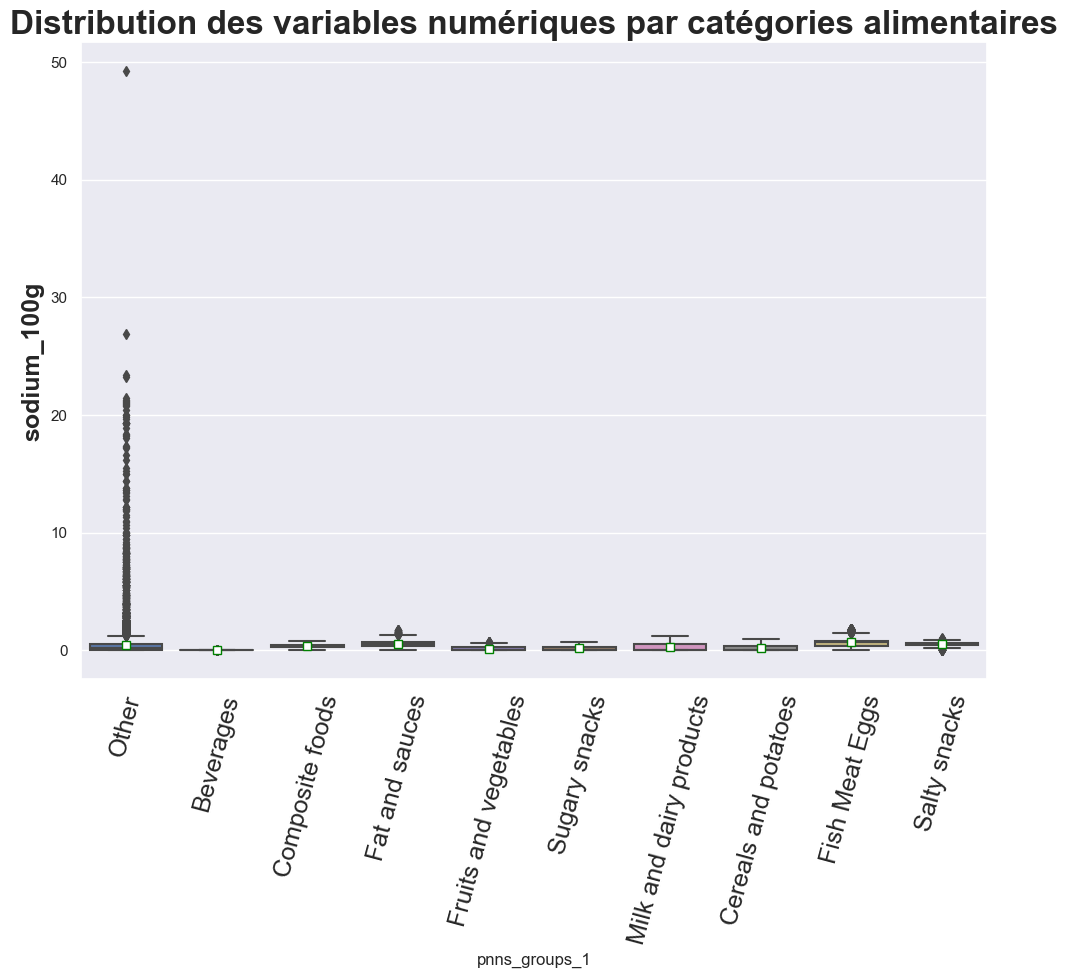

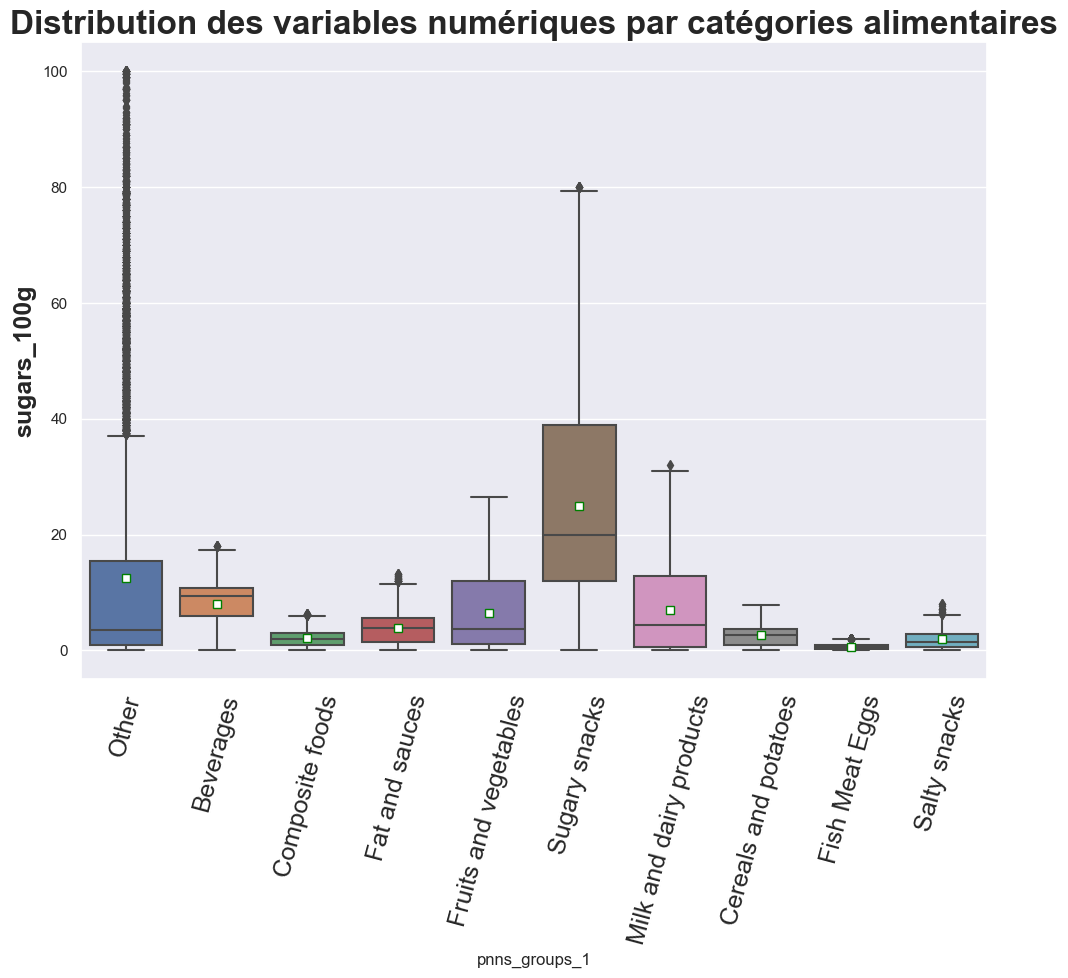

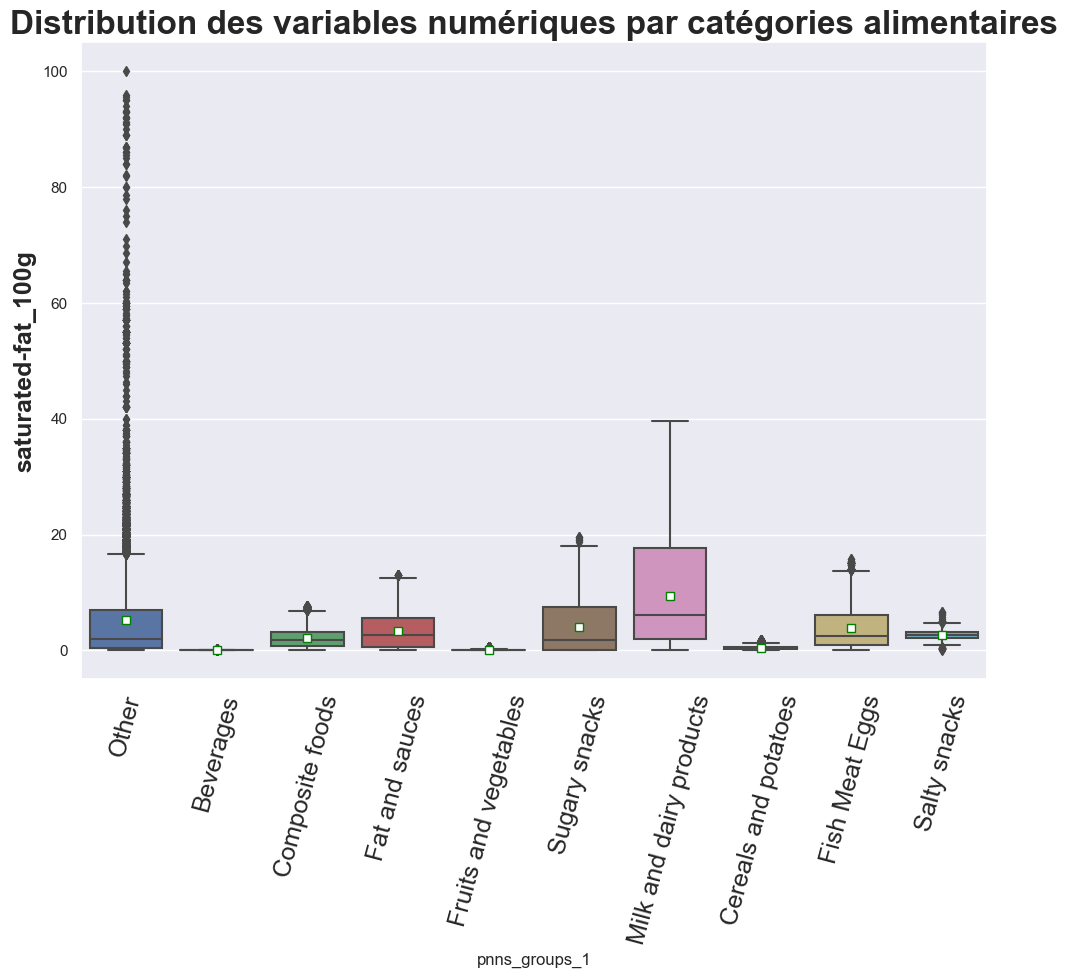

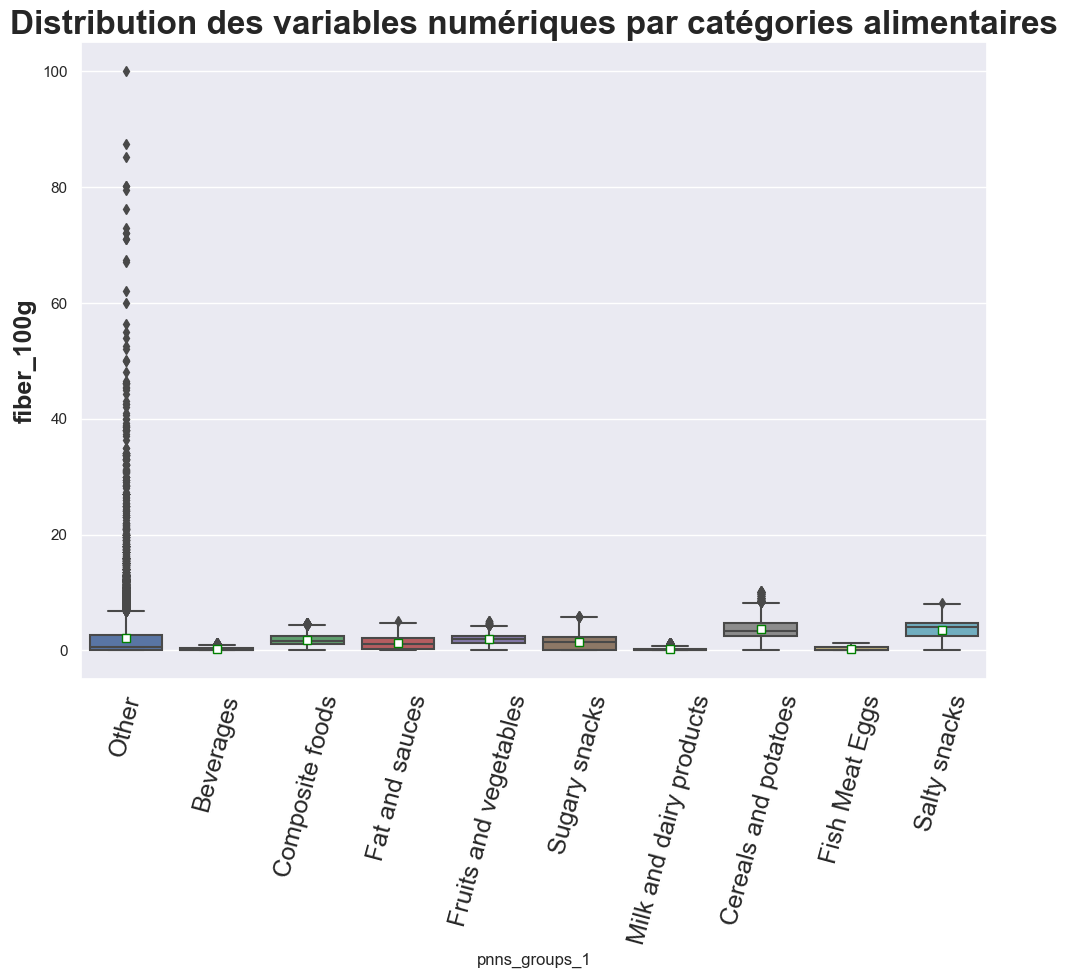

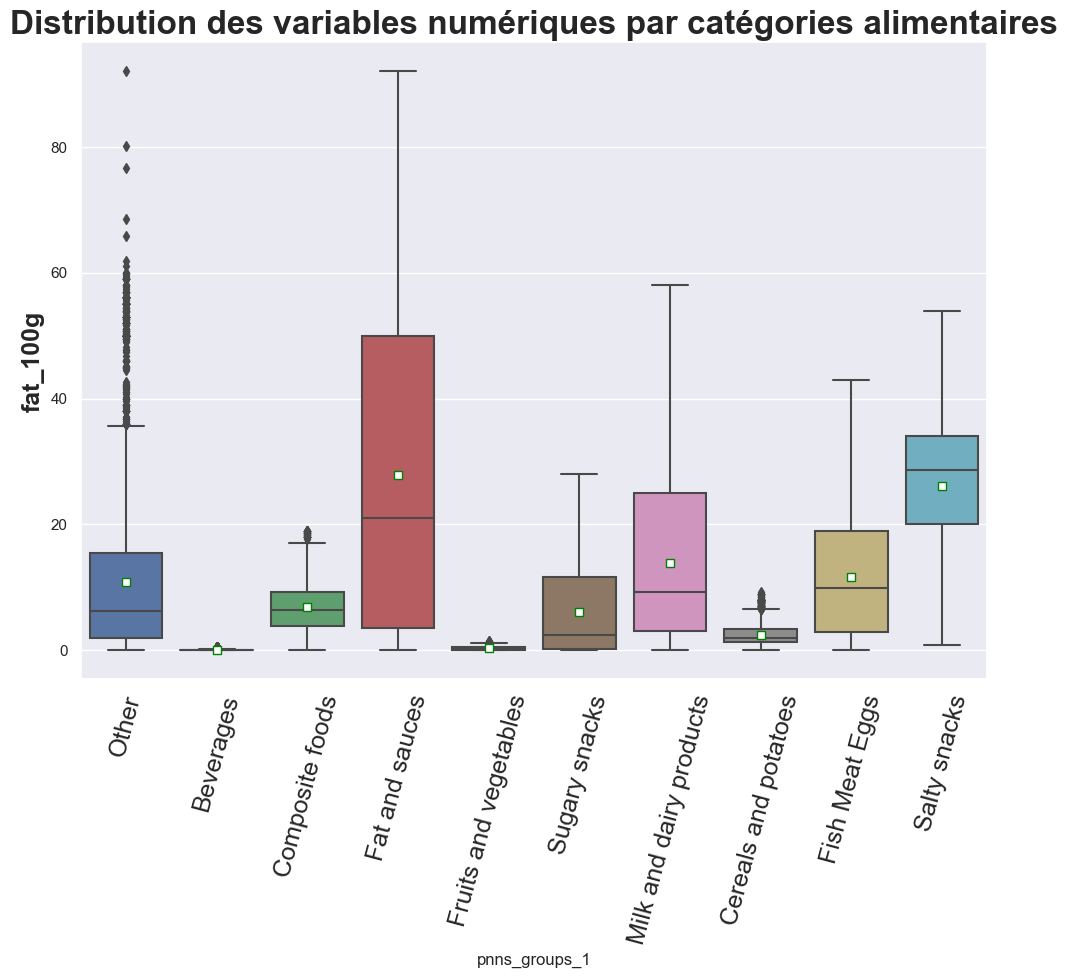

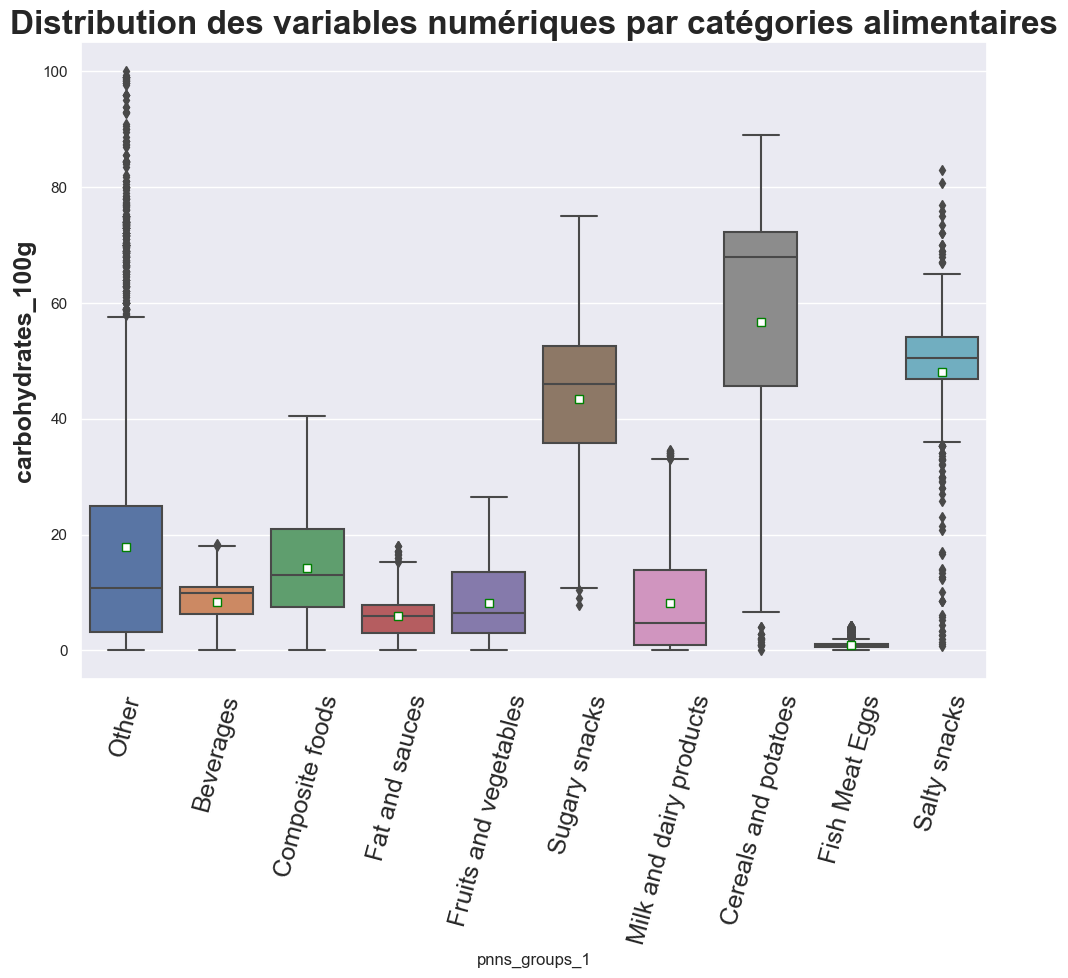

In [77]:
for num in num_cols:
    ax = sns.boxplot(data=sm_df, y=num
                            , x='pnns_groups_1'
                            , showmeans=True
                            , meanprops={"marker":"s","markerfacecolor":"white", "markeredgecolor":"green"})
    var = ax.set_xticklabels(ax.get_xticklabels(), rotation=75, fontsize= 18)
    plt.ylabel(f"{num}", fontsize=18, fontweight='bold')
    plt.title("Distribution des variables numériques par catégories alimentaires", fontsize=24, fontweight='bold')
    plt.show()

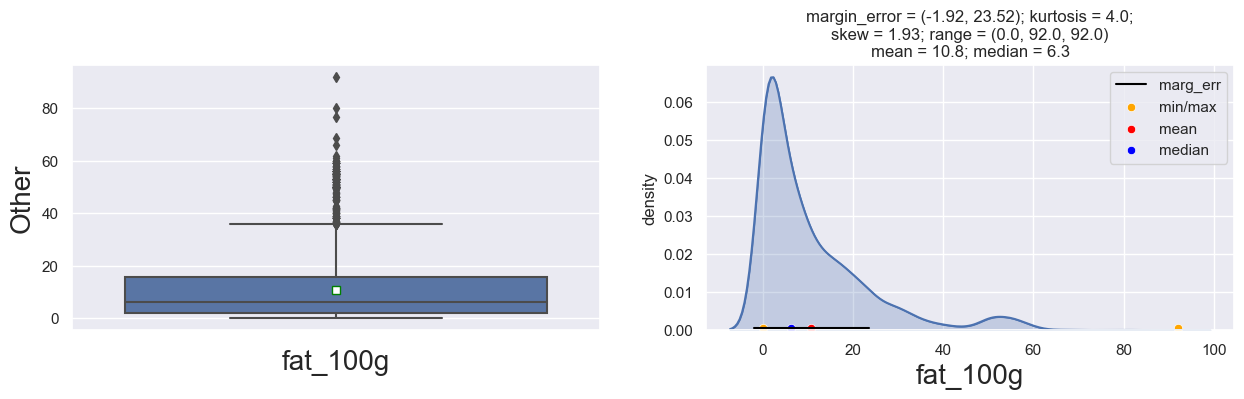

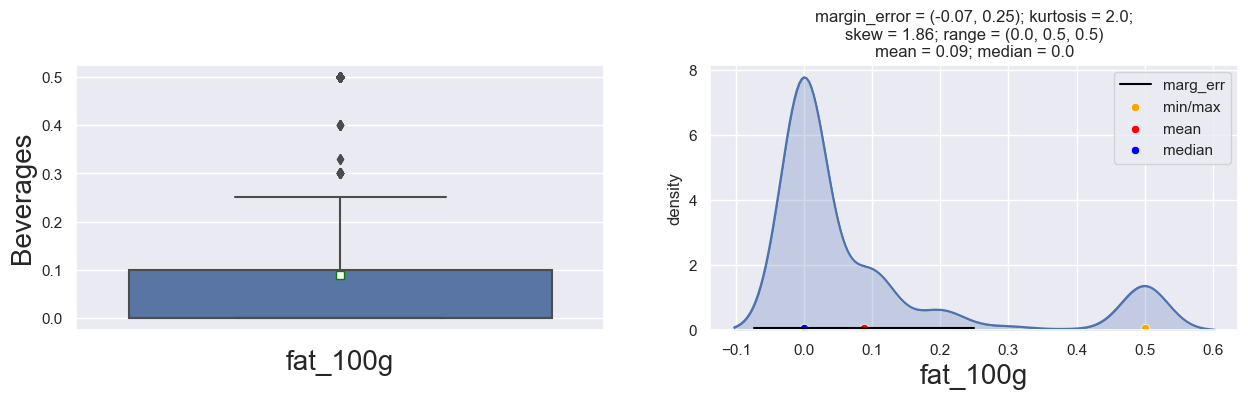

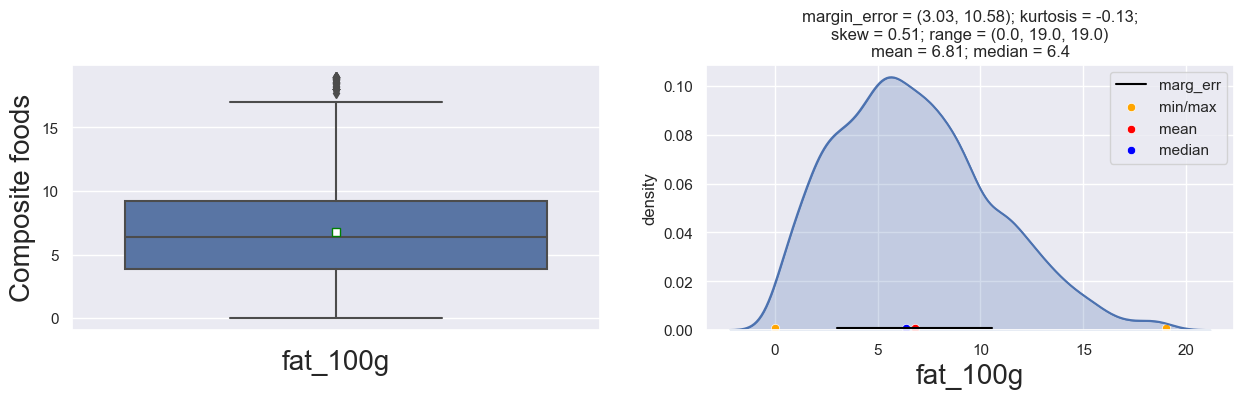

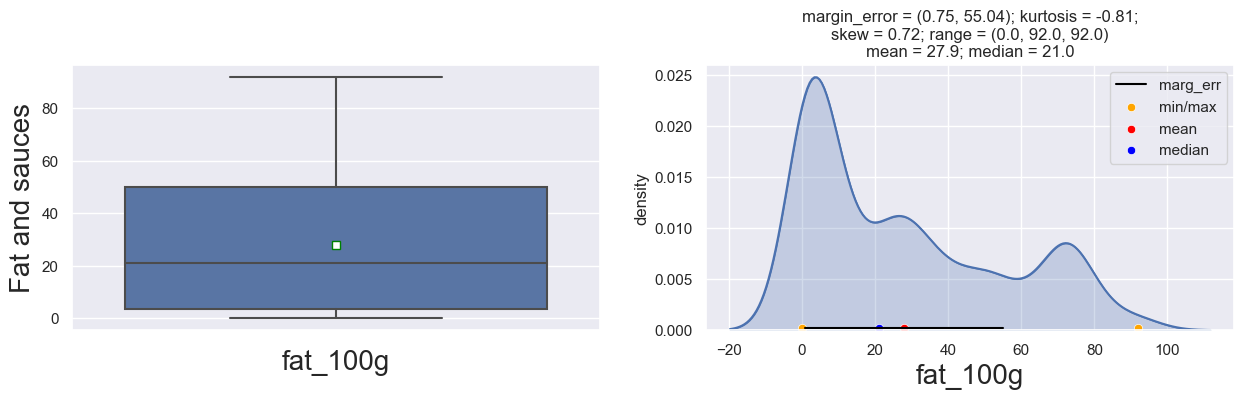

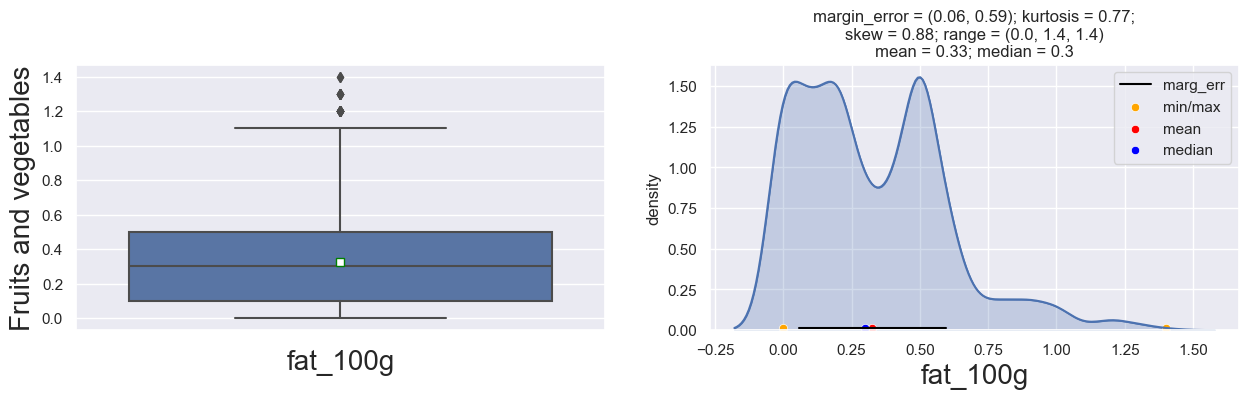

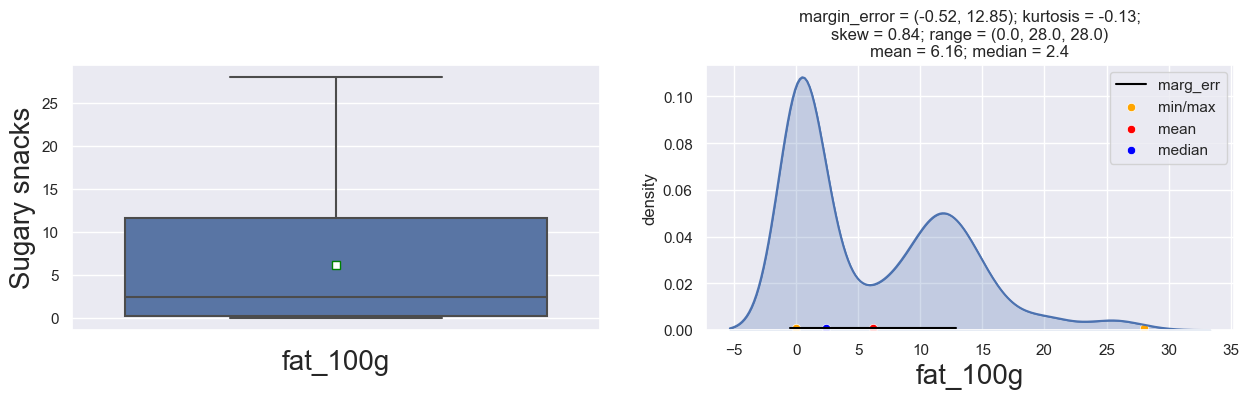

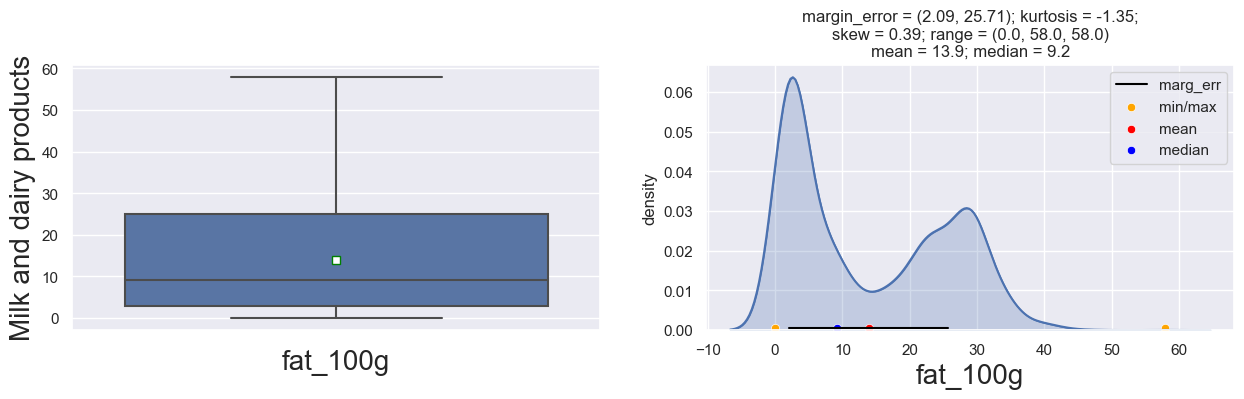

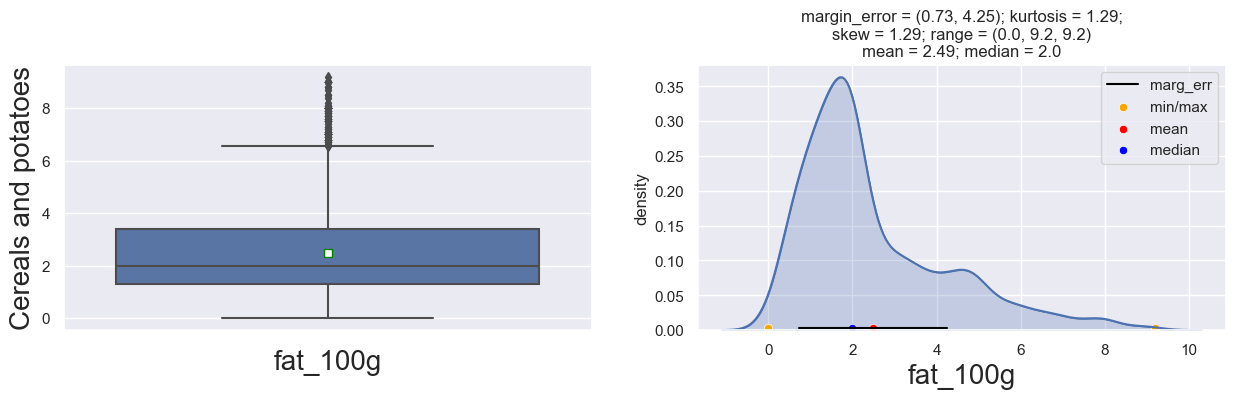

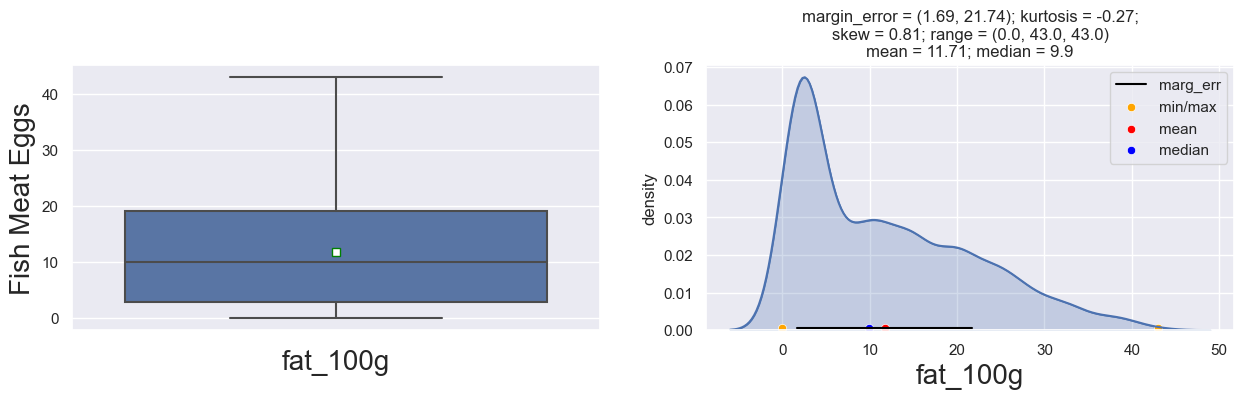

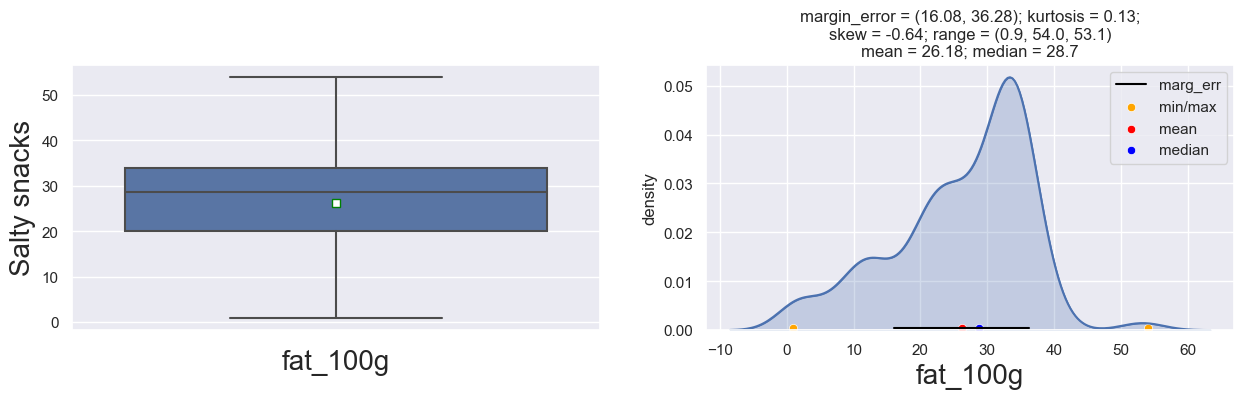

In [177]:
for pnn in pnns_1_list:
    UVA_num_plus_cat(sm_df.loc[sm_df['pnns_groups_1'] == pnn], ['fat_100g'], pnn)

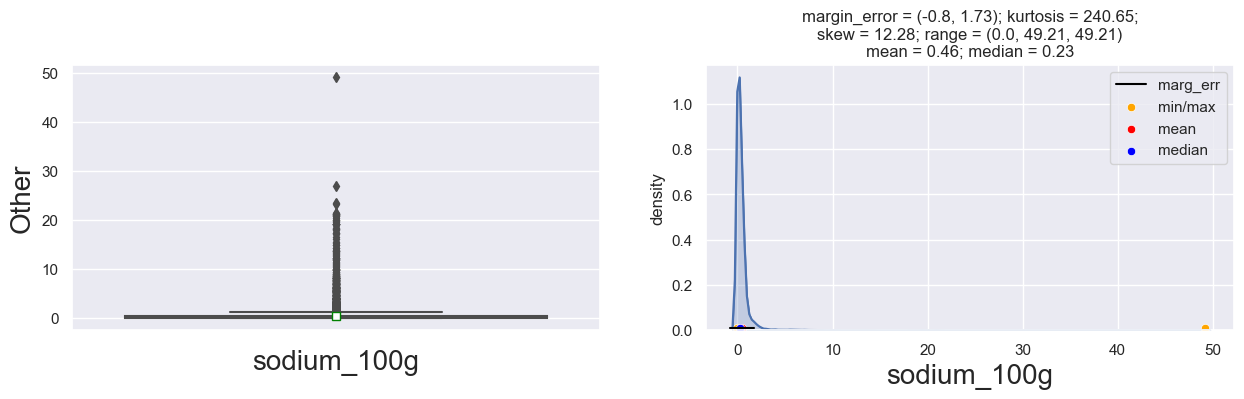

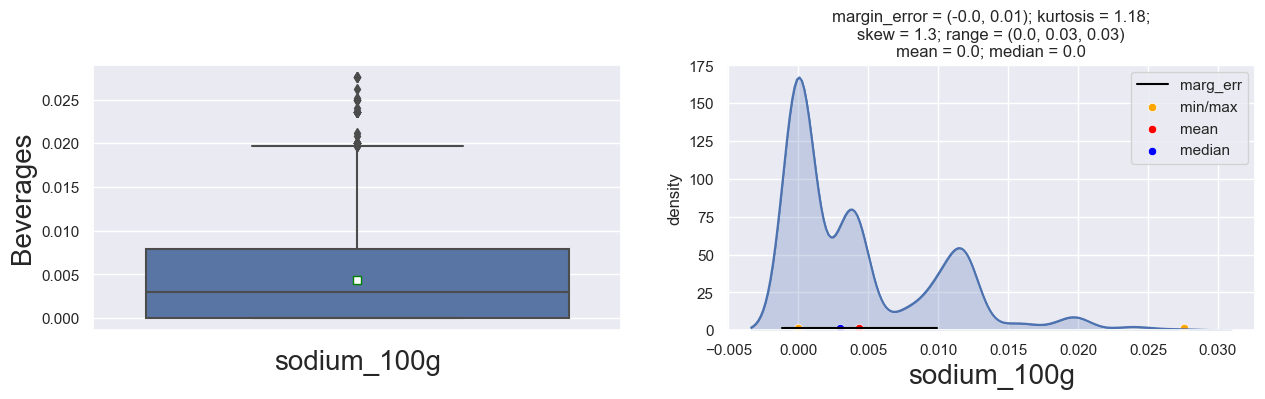

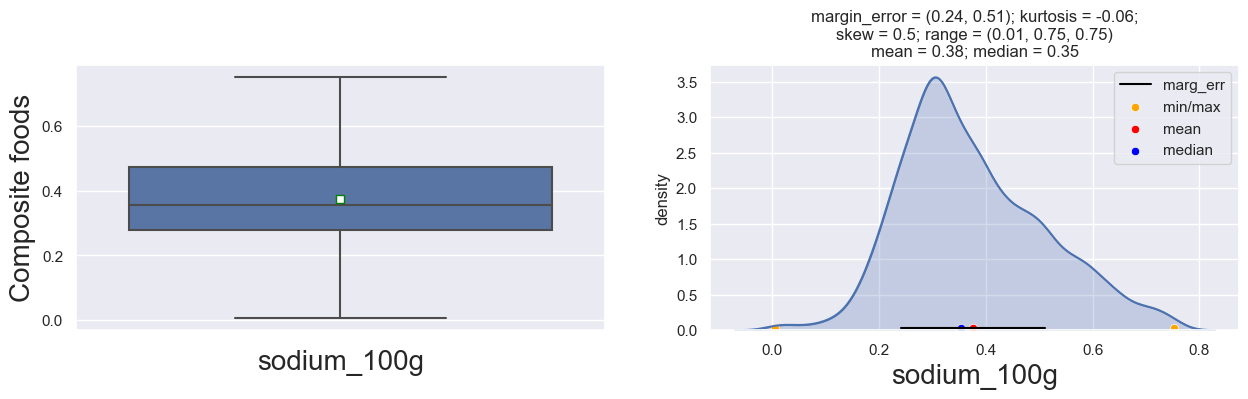

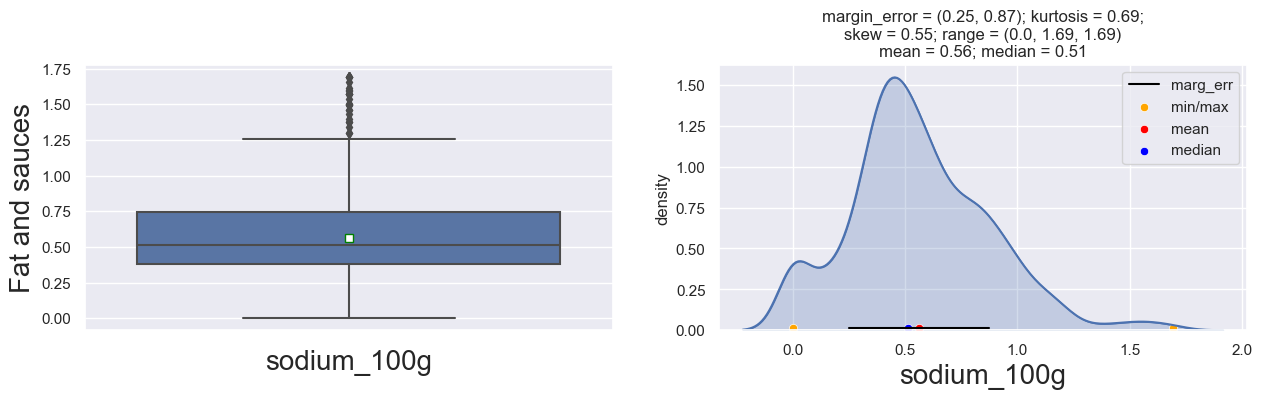

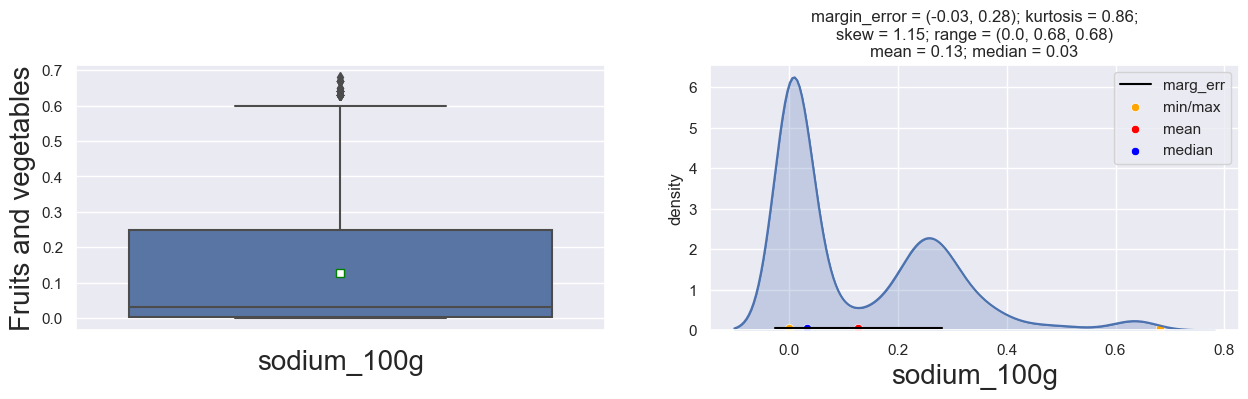

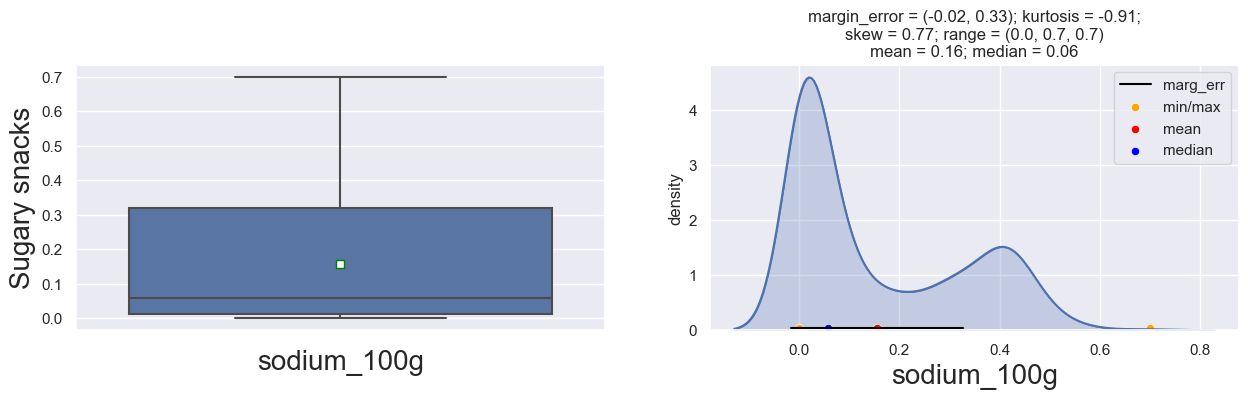

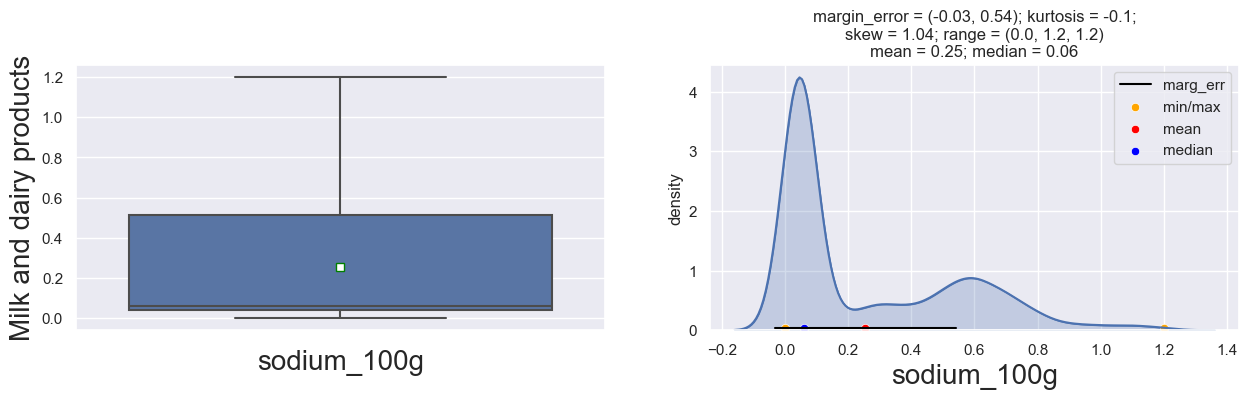

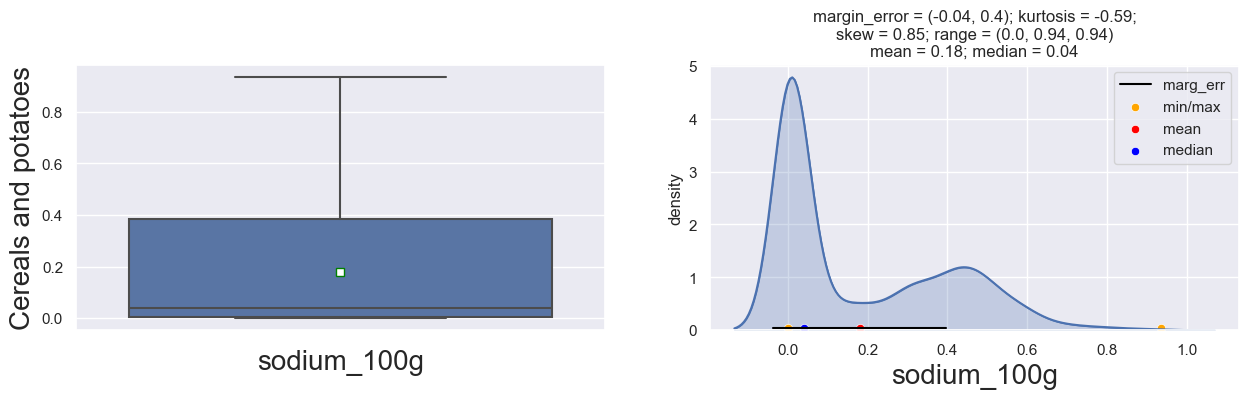

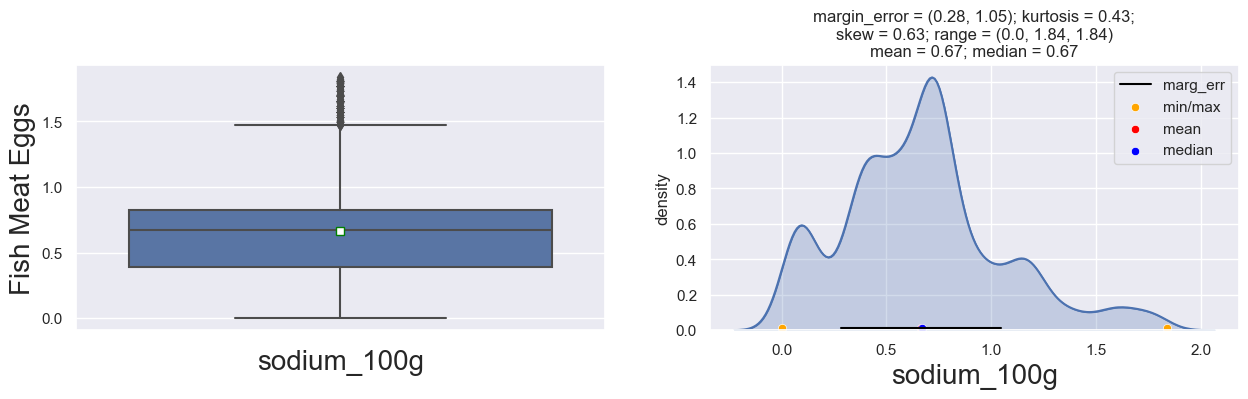

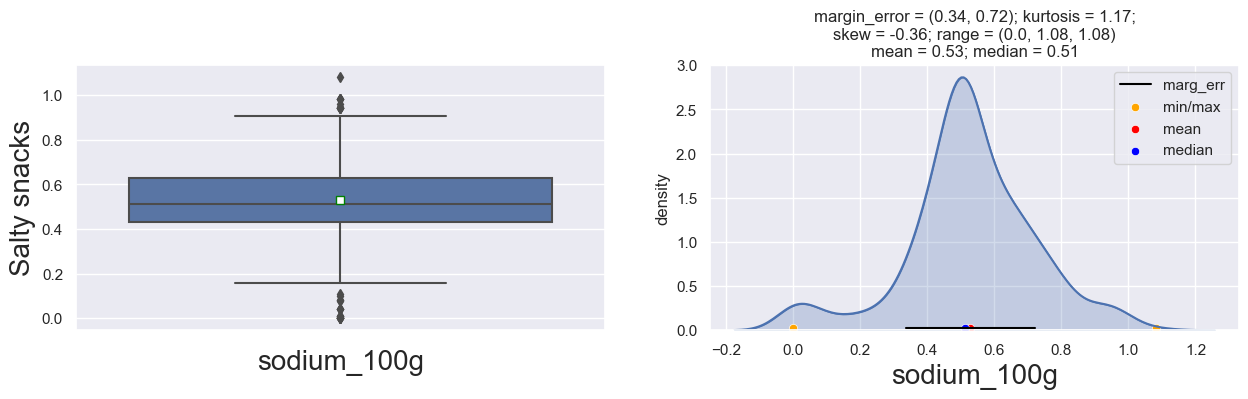

In [178]:
for pnn in pnns_1_list:
    UVA_num_plus_cat(sm_df.loc[sm_df['pnns_groups_1'] == pnn], ['sodium_100g'], pnn)

### sm_num_cols : all but carbohydrates_100g  => median input

In [179]:
show_nulls(sm_df)

                         count  null_percent
carbohydrates_100g       16172     39.998021
fat_100g                 16131     39.896617
fiber_100g                9836     24.327266
nutrition-score-fr_100g   8274     20.463989
energy_100g                226      0.558963
sugars_100g                 70      0.173130
salt_100g                   68      0.168184
proteins_100g               67      0.165710
sodium_100g                 67      0.165710
saturated-fat_100g          67      0.165710
code                         0      0.000000
nutrition_grade_fr           0      0.000000
product_name                 0      0.000000
pnns_groups_2                0      0.000000
pnns_groups_1                0      0.000000


In [180]:
#imp_med = SimpleImputer(missing_values=np.nan, strategy='median')

###sm_df[all_num_cols] = imp_med.fit_transform(sm_df[all_num_cols])

In [181]:
# sm_df[[c for c in df.columns if c in main_cats]].head()

In [182]:
num_cols_med_input = num_cols.tolist()
#num_cols_med_input.remove('carbohydrates_100g')
num_cols_med_input

['nutrition-score-fr_100g',
 'proteins_100g',
 'energy_100g',
 'salt_100g',
 'sodium_100g',
 'sugars_100g',
 'saturated-fat_100g',
 'fiber_100g',
 'fat_100g',
 'carbohydrates_100g']

In [183]:
sm_df.filter(num_cols_med_input).head()

,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g
0,14.0,0.6,1753.0,0.0100,0.003937,87.7,0.8,0.9,NaN,NaN
1,14.0,9.5,2406.0,0.0030,0.001181,50.3,2.9,3.9,NaN,NaN
2,13.0,0.0,177.0,0.0254,0.010000,10.4,0.0,0.0,0.0,10.4
3,15.0,7.5,1079.0,0.8000,0.314961,1.0,11.0,1.4,NaN,NaN
5,6.0,5.8,1272.0,0.7000,0.275591,12.7,1.7,0.0,NaN,NaN


In [184]:
sm_df_groupby = sm_df.groupby(by='pnns_groups_1')

In [185]:
sm_df.columns

Index(['code', 'nutrition_grade_fr', 'nutrition-score-fr_100g',
       'proteins_100g', 'energy_100g', 'salt_100g', 'sodium_100g',
       'sugars_100g', 'saturated-fat_100g', 'product_name', 'fiber_100g',
       'fat_100g', 'carbohydrates_100g', 'pnns_groups_2', 'pnns_groups_1'],
      dtype='object')

In [186]:
sm_df_groupby[num_cols_med_input].median()

,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g
pnns_groups_1,,,,,,,,,,
Beverages,6.0,0.2,176.0,0.00762,0.003000,9.4,0.00,0.0,0.0,9.9
Cereals and potatoes,1.0,9.7,1477.0,0.10000,0.039370,2.6,0.40,3.3,2.0,68.0
Composite foods,3.0,6.8,591.0,0.90000,0.354331,2.0,1.70,1.6,6.4,13.0
Fat and sauces,11.0,1.4,968.0,1.30000,0.511811,3.8,2.60,1.1,21.0,6.0
Fish Meat Eggs,5.0,20.0,674.0,1.70000,0.669291,0.5,2.40,0.0,9.9,0.7
Fruits and vegetables,1.0,0.9,161.0,0.08000,0.031496,3.6,0.03,1.9,0.3,6.4
Milk and dairy products,11.0,4.7,694.0,0.15000,0.059055,4.4,6.10,0.0,9.2,4.8
Other,11.0,5.8,1021.0,0.58000,0.228346,3.5,1.90,0.5,6.3,10.8
Salty snacks,12.0,6.1,2114.5,1.30000,0.511811,1.5,2.70,4.0,28.7,50.5


In [187]:
sm_df_groupby[num_cols_med_input].count()

,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g
pnns_groups_1,,,,,,,,,,
Beverages,2822,2849,2849,2849,2849,2849,2849,1814,2400,2410
Cereals and potatoes,747,2625,2625,2625,2625,2625,2625,2209,2480,2489
Composite foods,3063,3990,3990,3990,3990,3990,3990,2709,3891,3889
Fat and sauces,1235,1296,1283,1296,1296,1296,1296,755,1197,1198
Fish Meat Eggs,2980,3327,3323,3327,3327,3327,3327,1377,3176,3168
Fruits and vegetables,240,1986,1986,1986,1986,1986,1986,1706,1868,1876
Milk and dairy products,4066,4393,4390,4393,4393,4392,4393,2007,4174,4128
Other,15618,18484,18348,18483,18484,18482,18484,17074,4028,4013
Salty snacks,374,388,388,388,388,388,388,203,352,351


In [188]:
# https://pandas.pydata.org/docs/user_guide/groupby.html

sm_df[num_cols_med_input] = sm_df_groupby[num_cols_med_input].transform(lambda x: x.fillna(x.median()))

In [189]:
sm_df.isna().sum()

code                       0
nutrition_grade_fr         0
nutrition-score-fr_100g    0
proteins_100g              0
energy_100g                0
salt_100g                  0
sodium_100g                0
sugars_100g                0
saturated-fat_100g         0
product_name               0
fiber_100g                 0
fat_100g                   0
carbohydrates_100g         0
pnns_groups_2              0
pnns_groups_1              0
dtype: int64

In [190]:
show_nulls(sm_df)

                         count  null_percent
code                         0           0.0
nutrition_grade_fr           0           0.0
nutrition-score-fr_100g      0           0.0
proteins_100g                0           0.0
energy_100g                  0           0.0
salt_100g                    0           0.0
sodium_100g                  0           0.0
sugars_100g                  0           0.0
saturated-fat_100g           0           0.0
product_name                 0           0.0
fiber_100g                   0           0.0
fat_100g                     0           0.0
carbohydrates_100g           0           0.0
pnns_groups_2                0           0.0
pnns_groups_1                0           0.0


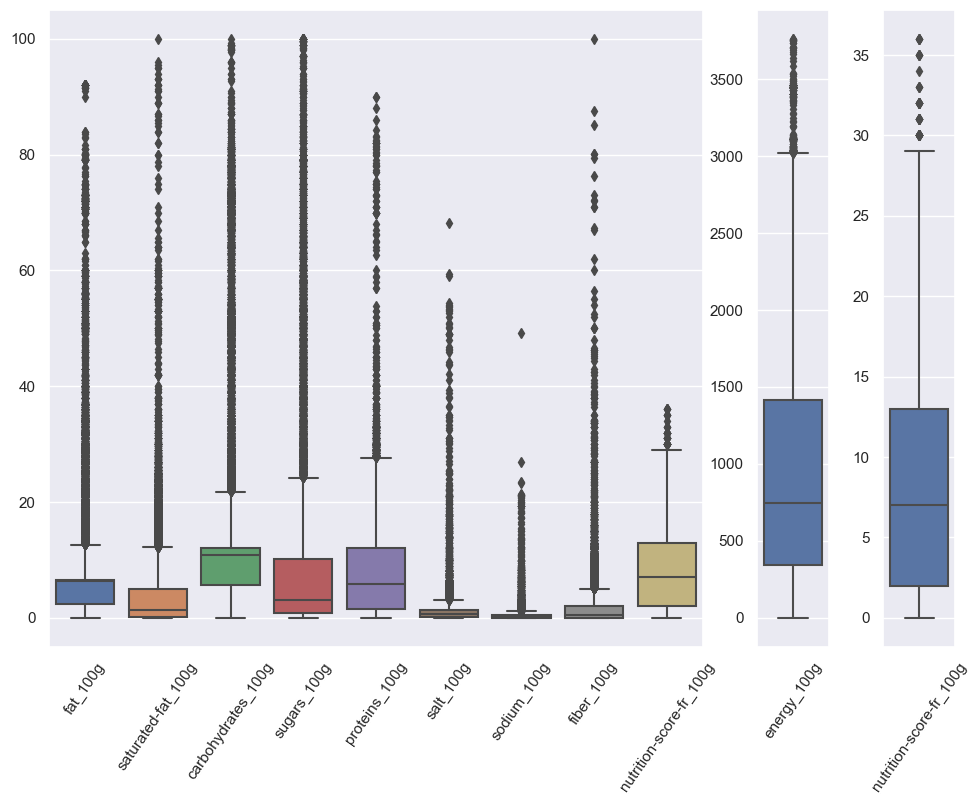

In [191]:
boxplot_nums(sm_df, [sm_num_cols, energy_cols, scores_cols])

In [192]:
#sm_df_gr_transf = sm_df_groupby[main_cats].transform(lambda x: x.fillna(x.mean()))
#sm_df_gr_transf

In [193]:
#grouped.transform(lambda x: x.fillna(inplace=False))

## carbohydrates_100g : mean inputing

In [194]:
#num_cols_mean_input = ['carbohydrates_100g']

In [195]:
#sm_df_groupby[num_cols_mean_input].mean()

In [196]:
#sm_df[num_cols_mean_input] = sm_df_groupby[num_cols_mean_input].transform(lambda x: x.fillna(x.mean()))

# Check nulls

In [197]:
sm_df.shape

(40432, 15)

In [198]:
show_nulls(sm_df)

                         count  null_percent
code                         0           0.0
nutrition_grade_fr           0           0.0
nutrition-score-fr_100g      0           0.0
proteins_100g                0           0.0
energy_100g                  0           0.0
salt_100g                    0           0.0
sodium_100g                  0           0.0
sugars_100g                  0           0.0
saturated-fat_100g           0           0.0
product_name                 0           0.0
fiber_100g                   0           0.0
fat_100g                     0           0.0
carbohydrates_100g           0           0.0
pnns_groups_2                0           0.0
pnns_groups_1                0           0.0


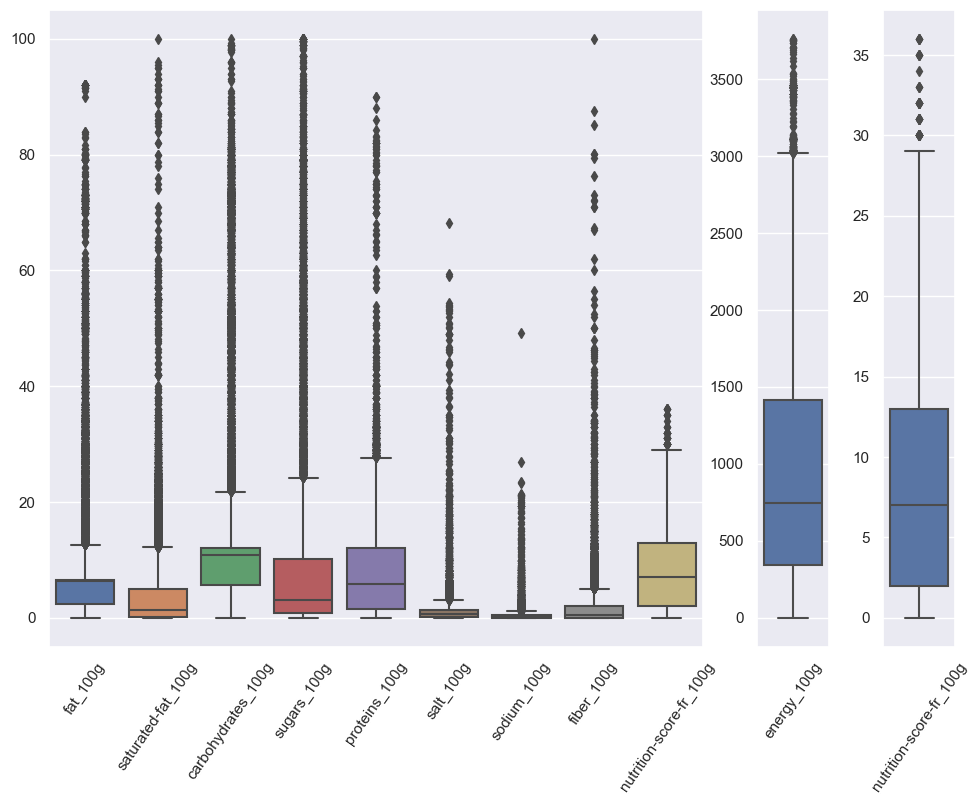

In [199]:
boxplot_nums(sm_df, [sm_num_cols, energy_cols, scores_cols])

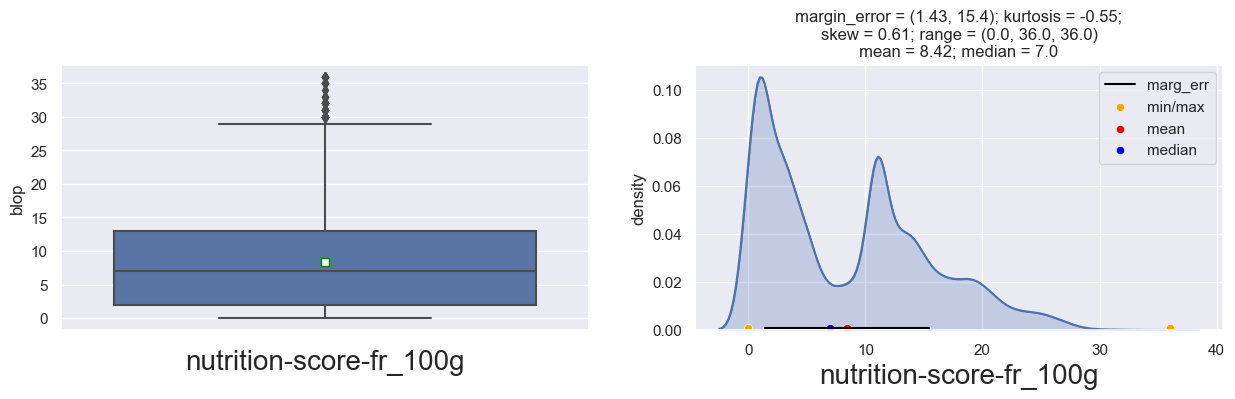

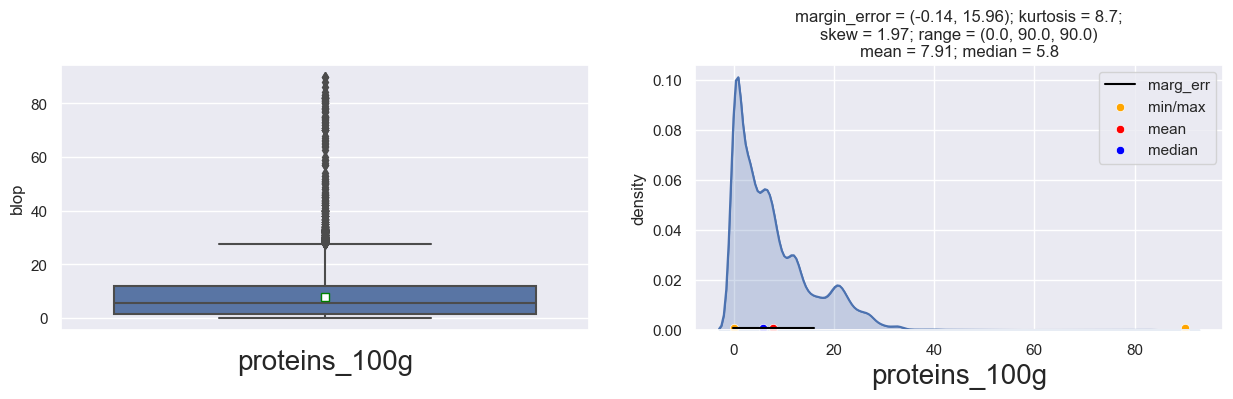

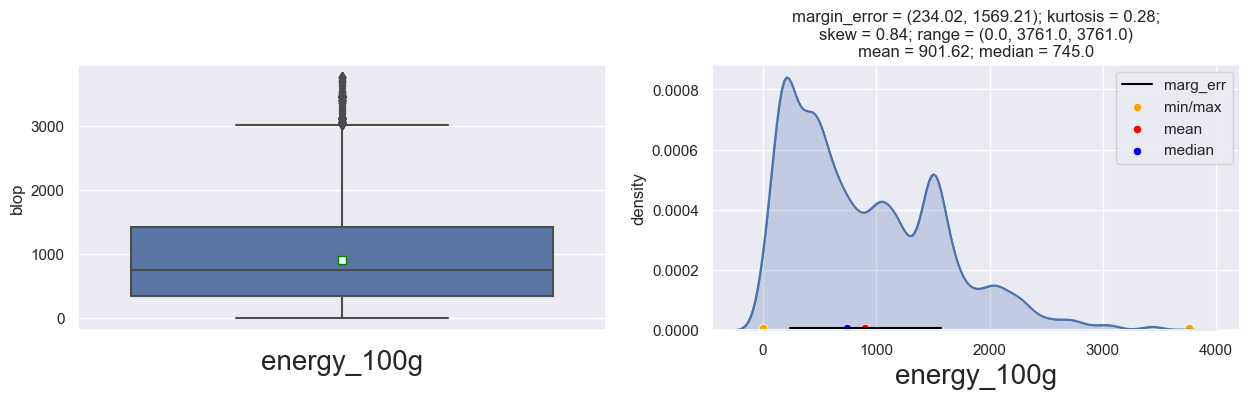

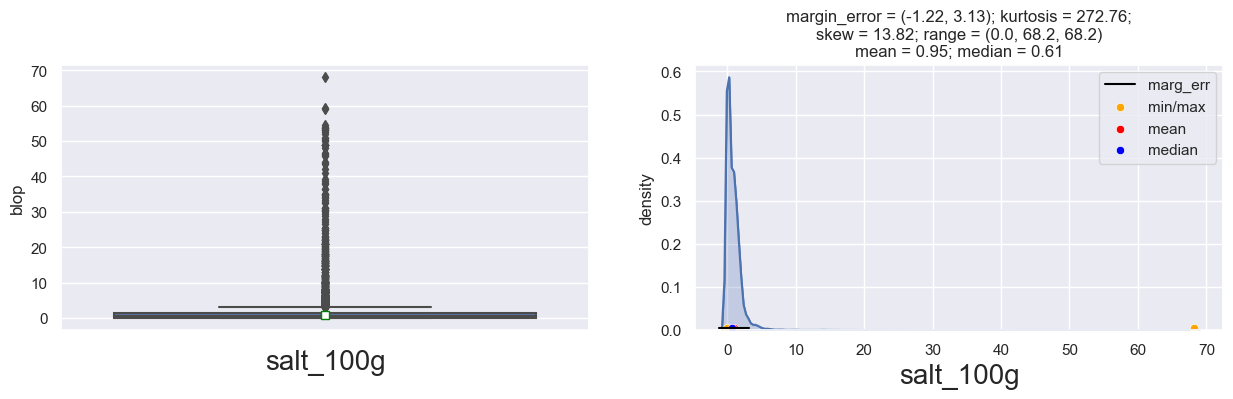

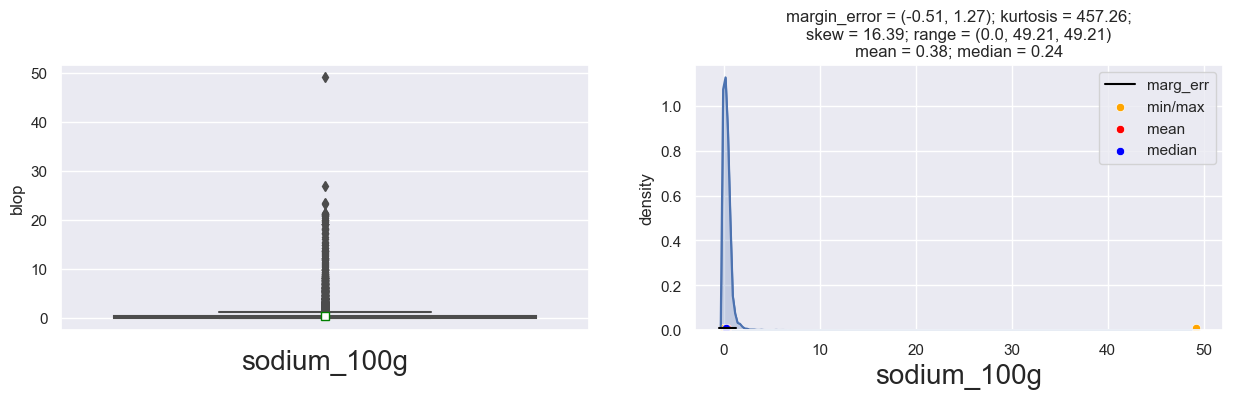

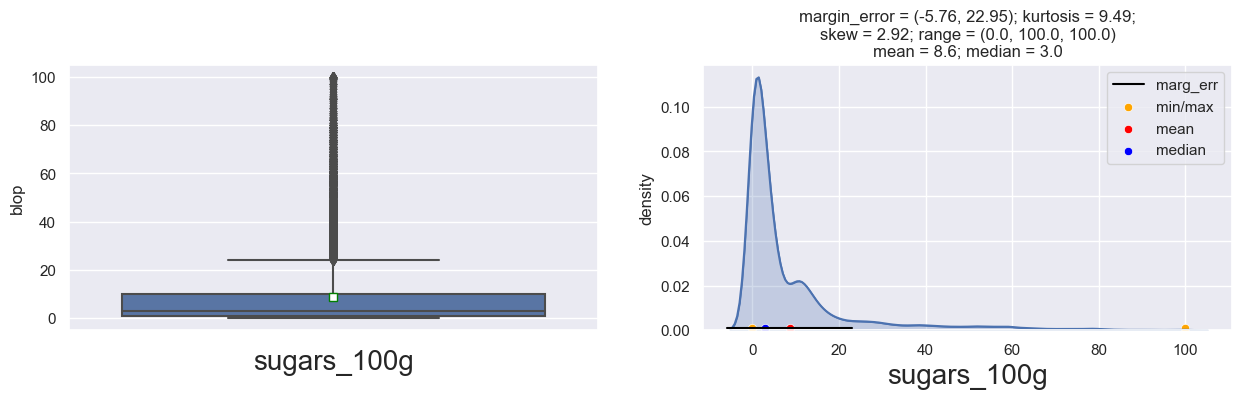

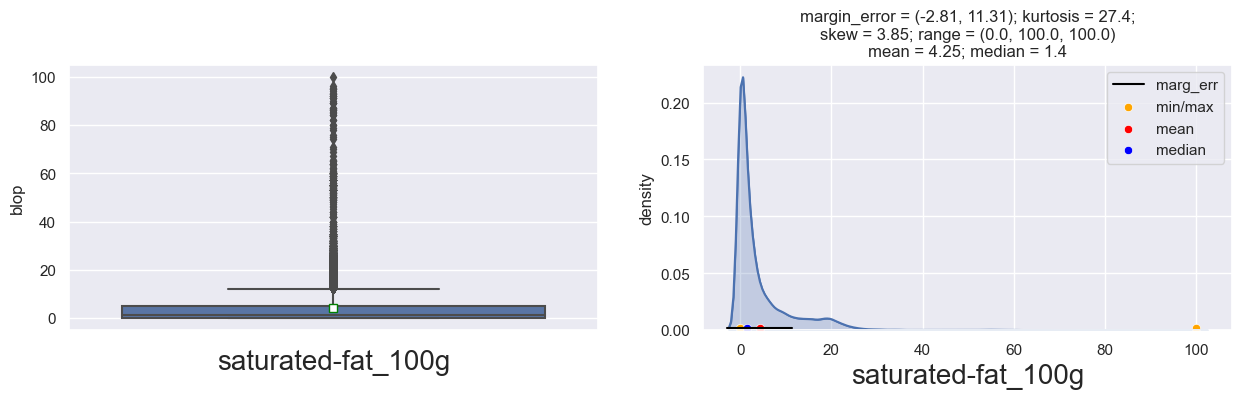

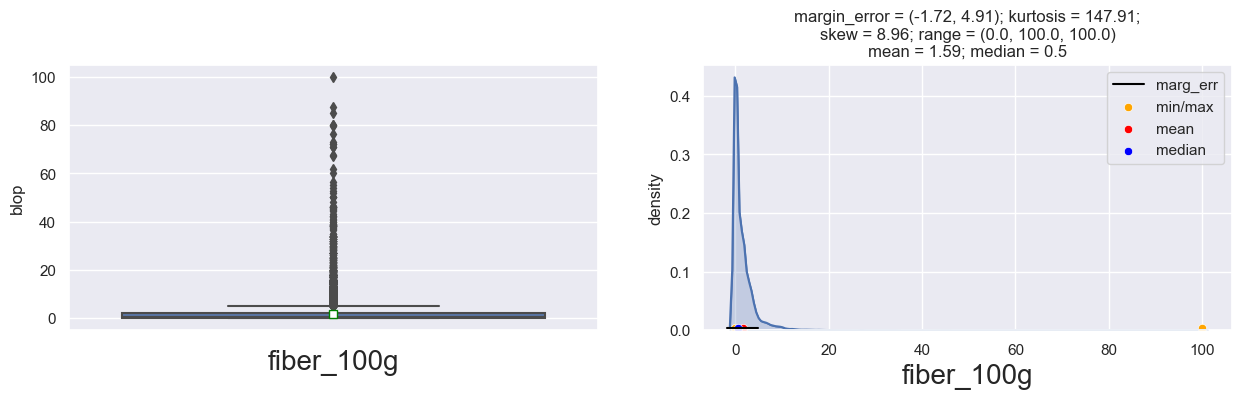

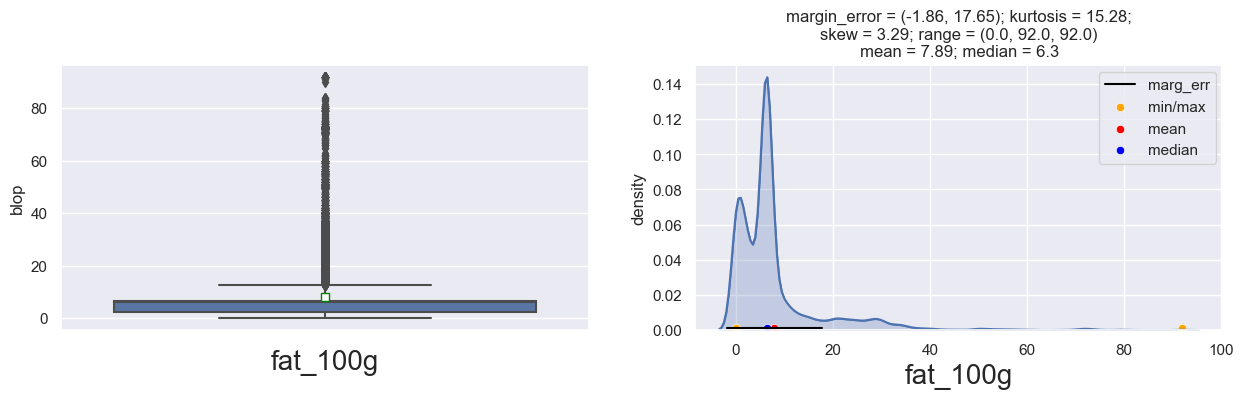

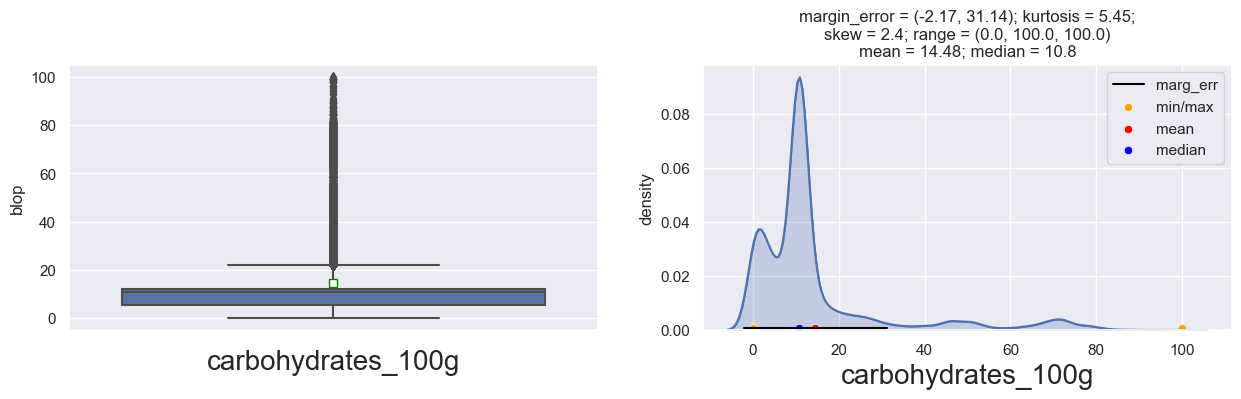

In [200]:
UVA_num_plus(sm_df, num_cols)

# export to csv

In [201]:
#sm_df.reset_index()

sm_df.to_csv(path + 'clean_openfoodfacts_3.csv', index=False)
print('export finished !')

export finished !


In [202]:
ls -lh ./data

Le format du paramŠtre est incorrect - "data".
